# Projeto end-to-end de risco de crédito
## Modelos baseados em árvores, custo de decisão e governança

Este notebook transforma o Capítulo 8 de *An Introduction to Statistical Learning with Applications in Python* em um projeto de concessão de crédito. A tarefa é estimar o risco de um contrato e decidir se a proposta deve ser aprovada ou encaminhada para recusa ou revisão.

O projeto combina:

1. árvores de classificação, poda, bagging, random forest, boosting e BART, conforme o ISLP;
2. formulação, separação do teste, pipelines, avaliação e persistência, conforme o *Hands-On Machine Learning*;
3. baselines, validação repetida e inspeção de modelos, conforme o curso da Inria;
4. matriz de custo, Gini, KS, calibração, limiar operacional, análise de erros e auditoria por grupos, conforme uma rotina de risco de crédito.

O objetivo é aprender a construir uma decisão defensável. Desempenho preditivo, custo, estabilidade, interpretação e risco de uso serão avaliados juntos.

> **Execução autônoma:** o conjunto de dados está compactado dentro do notebook. Nenhum download é necessário.

## O que você deverá saber ao terminar

Você deverá conseguir explicar:

- como uma árvore escolhe divisões e por que uma árvore profunda tem alta variância;
- como `ccp_alpha` produz poda por complexidade de custo;
- por que bagging e random forest estabilizam árvores;
- como boosting aprende sequencialmente os erros restantes;
- por que uma regressão logística continua sendo um baseline forte em crédito;
- como a incerteza da validação muda quando há somente 1.000 observações;
- por que um limiar de 0,5 pode produzir uma decisão comercial ruim;
- como a matriz de custo da UCI leva a um limiar teórico de aproximadamente 0,167;
- como engenharia de atributos e exclusões de governança afetam o resultado;
- como salvar transformação, codificação, modelo, esquema e limiar em um pickle.

## Mapa do projeto

| Bloco | Questão técnica | Questão de crédito | Evidência |
| --- | --- | --- | --- |
| Formulação | O alvo representa qual evento? | Qual erro gera maior perda? | contrato e matriz de custo |
| Dados | Há informação suficiente e representativa? | A amostra serve para o mercado pretendido? | EDA e limitações |
| Árvore | Qual complexidade generaliza? | Uma regra curta é estável? | árvore rasa, bootstrap e poda |
| Ensembles | A combinação reduz variância? | O ganho compensa opacidade e tamanho? | CV repetida, OOB, tempo e tamanho |
| Política | Qual limiar minimiza custo? | Aprovar ou rejeitar em qual ponto? | curva de custo OOF |
| Teste | O modelo resiste fora do desenvolvimento? | Quanto custa a política congelada? | AP, AUC, Gini, KS, Brier e matriz de confusão |
| Operação | A mesma engenharia chega à inferência? | Como impedir colunas proibidas e esquema quebrado? | pickle e contrato de entrada |

## 0. Formulação antes do código

**Unidade de análise:** um contrato de crédito.

**Momento da previsão:** durante a análise da proposta, antes da decisão de concessão.

**Alvo:** `bad = 1` para mau risco de crédito e `bad = 0` para bom risco.

**Saída do modelo:** probabilidade estimada de mau risco.

**Ação:** probabilidade acima do limiar gera recusa ou revisão; abaixo do limiar gera aprovação.

**Matriz de custo fornecida com os dados:**

| Real \ Decisão | aprovar como bom | recusar como mau |
| --- | ---: | ---: |
| bom | 0 | 1 |
| mau | 5 | 0 |

Um mau pagador aprovado custa cinco unidades. Um bom pagador recusado custa uma unidade. As unidades não são euros nem perda esperada contábil. Elas representam a preferência decisória do dataset.

### Pergunta profunda 1

Por que o custo deve ser definido antes de escolher o limiar?

<details>
<summary>Resposta guiada</summary>

O mesmo ranking produz decisões distintas quando a relação entre falso negativo e falso positivo muda. O limiar pertence à política. Escolhê-lo depois de observar o teste transforma a avaliação final em ajuste disfarçado.

</details>

## 1. Fundamentos do Capítulo 8

### 1.1 Divisão binária e impureza

Uma árvore procura o atributo $j$ e o corte $s$ que criam duas regiões:

$$R_1(j,s)=\{X\mid X_j<s\}, \qquad R_2(j,s)=\{X\mid X_j\geq s\}.$$

Para classificação, a impureza de Gini do nó $m$ é:

$$G_m=\sum_{k=1}^{K}\hat p_{mk}(1-\hat p_{mk}).$$

Gini próximo de zero indica um nó mais puro. A escolha do corte é gulosa: a melhor divisão local não garante a melhor árvore global.

**Uso em crédito:** a árvore aprende limiares e interações sem exigir forma linear. Um corte observado na amostra continua sendo associação, não causa de inadimplência.

### 1.2 Poda

A poda por complexidade de custo minimiza:

$$R_\alpha(T)=R(T)+\alpha|T|,$$

em que $R(T)$ mede o ajuste e $|T|$ é o número de folhas. `ccp_alpha` maior elimina mais ramos. O valor será escolhido por validação cruzada dentro do desenvolvimento.

### 1.3 Bagging e random forest

Bagging ajusta árvores em amostras bootstrap e combina suas previsões:

$$\hat f_{bag}(x)=\frac{1}{B}\sum_{b=1}^{B}\hat f^{*b}(x).$$

Random forest sorteia atributos em cada divisão para reduzir a correlação entre árvores. A média de árvores menos correlacionadas tende a ter menor variância.

### 1.4 Boosting

Boosting adiciona árvores em sequência. Cada árvore reduz a perda deixada pelo conjunto atual. A taxa de aprendizagem e o número de árvores precisam ser avaliados em conjunto.

### 1.5 BART

Bayesian Additive Regression Trees usa uma soma de árvores pequenas sob uma distribuição posterior. A incerteza posterior é uma vantagem. O benchmark deste notebook usa a API do scikit-learn para manter o ambiente reproduzível; BART fica como extensão de estudo, pois exigiria outra dependência e diagnóstico de amostragem.

## 2. Ambiente e reprodutibilidade

Todas as transformações que aprendem parâmetros ficarão dentro de `Pipeline`. O pickle final armazenará decodificação, atributos derivados, imputação, escala, one-hot, modelo e limiar de decisão.

In [ ]:
import base64
import gzip
import hashlib
import io
import pickle
import platform
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from joblib.externals import cloudpickle

from sklearn import __version__ as sklearn_version
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

SEED = 42
COST_FALSE_GOOD = 5
COST_FALSE_BAD = 1

np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

versions = pd.Series({
    "Python": platform.python_version(),
    "pandas": pd.__version__,
    "NumPy": np.__version__,
    "scikit-learn": sklearn_version,
    "joblib": joblib.__version__,
}, name="versão")
versions.to_frame()

,versão
Python,3.14.3
pandas,2.3.3
NumPy,2.4.3
scikit-learn,1.8.0
joblib,1.5.3


**Leitura do bloco:** a versão acompanha o modelo porque objetos serializados pelo scikit-learn podem falhar ou mudar de comportamento em outro ambiente. Reprodutibilidade exige dados, semente, código, biblioteca e regra de decisão.

## 3. Dados e proveniência

O German Credit foi disponibilizado por Hans Hofmann e contém 1.000 contratos, 20 atributos, 700 bons riscos e 300 maus riscos. A versão simbólica preserva 13 atributos categóricos e 7 numéricos.

Os valores monetários usam marco alemão. O conjunto é histórico, pequeno e sem timestamp. Ele serve para ensino e não representa a carteira de uma instituição brasileira atual.

In [4]:
COLUMN_NAMES = [
    "checking_status", "duration_months", "credit_history", "purpose",
    "credit_amount", "savings_status", "employment_since", "installment_rate",
    "personal_status_sex", "other_debtors", "residence_since", "property",
    "age", "other_installment_plans", "housing", "existing_credits",
    "job", "dependents", "telephone", "foreign_worker", "credit_quality",
]

DATA_B64 = "H4sIAJBDi2oC/61dR9o1J66e91rOAAXS0Pvf1K0IopAEn30H/bTb/btcdQCh8IZ/AH7p9w/x7x+mH0Cqv39S/P2T4+/4W5V+/0CA8y8Bjz+Yj//m8+9F/OHxX/n4R47/qsdf4/HH4H/HH/txOZ6H1/Nijcf/n47/HH/y+FvnHzyfh/fzEMXzQDwP7ufh8Tz+HY+83y/9MNT0PI+v5z3vR/fzuH6fd7/m+7zz/Y4/hc/74S+XgvPz6P7e40tiex697zc/D48/Tccf4nB8eg7te+nz+/Evkngezs+7v5fS837pV0OMz3qQ/N7neTS93/O9Yj34fr/7e7Gc/0iia32/74fy/dT1uNe3vd+xIeq52GJ9SawvyfeD+3k87Zdnfe/9QiGe+4/besC4/2BeX+X9wrNfwi/i+RfX+10PqTy8H5bvfuZp/2F/v3D8ZY3P8/D6/Z79DM/zpu+d9zP081F/TKFoz3vW41y51fNQ/n4QzyP6rAfM72edN5z28/37AdT6PG+OB/RL4fv7ofK9EPvvx8fhUuIBT+sB1v6Dvp+P/xOv84vX8/gTX47thP5+wX4+7viHfP4PI/59zgda73ftv3CtbwkZn+fhFK/e/QL388g6b+17j7+BMY8LIj+Yf8zfgDAeOBwDwvEL8fmmc0B4f0CYN8wcYGrbLwjtvJGyX1ieN7L2X2pvh4nz83akhXvleMzhGXo4QGRoxw3m58nth9/rA5/laNfR8egS+Nl+qIRT8X5mOOX+fse/LLTr9/5eHo9v8rYffn6+439T5iEa0HD7UhK7T56OYXHTs5mP1cM0bD0e1pbqOjbT/ePB/bjwhnqSoe9dC/yuhXY0ct8qDHG+eal968ZSwBXPrpu8/lKh/rXzTZ7Iz4SeyNwj/fFvoudz763Cw+fOa2FG5nttOWBwbl68MjVc3OTt/Y6bsqTUIqlyk4d15icyteN7MdmR9MiE8vfomrvl2cvc9jLKwAf3USP6/n6sZaaxRfrjcWl4nvxelDe5ebPxfZPfmWkCCNpZoydTg/Z+ZK0v9fU4lgBCmCMptv28WF+8nxee551Lg9HL1PI6M8Ar0N+vx7Focf7ZzbgV+Cj0r6VzAZ9riI3dp6zuuJtFHgTX+1GLBmAHUvNrr9U4o0H8JQys/Xo8XURo5eHQ89IzkS35OW3Xl3xi6ZD3mXlG233n85i0tOA9baXtFrJ38/HIlvdRJe208ZTXq3kzjHXMmXheeSQZeeR8d6jRuadBFPF5HMg09z289A0uoAWr/rkZsWiH97nHh9dDPVgNZQyGTHNa2g7vUHaAm/bRnRfcxyNawaoaF/n4vPw8D46yPMW2XWAj2C/KtiPYo1b24lQWeXlQaetLlItW9r7BHnaO77X96Mn7MJplzHsZwVCWz1lzejKXY7sUam8HU6pxBxd0mxBDsEqc3q+F6WuPt5uKGC2np97EqTEls+ny5vToFjEkUwOoCYZUaHwekvF+Y1GUWpabEOscXPBdjeH04pyW4nAV1TNWjT0mmTTDkwnBKtb3zODYBHnOXOiN9THs9MAotRoQaiRn84mehlmyPT2153nMCF7qF/3TMdeAUMAM9rh1WfIdXfC6LCPU4BTRQxHIVk0po+kZv9/3m/fzHP3ISw6O/RxCbpUHzxsGt5KX3qQ7fr5qFr0sUzWy10NellS5xZf58t2LpqJJV4BIawo9t8ecXGnPy+18ZFJX93kaJ//03tGgZS5niymxU2hF+MZmnnYL3i3du/CINfLQ0sVhdRnE1xp3OQyrW3N2ChkO6+gMQ88gfsroTzhI3xaxFk1ZtEz7XY5TKk7LwvcpVOG5K8/CqJ02nlJdfNZjtfvOJbjCFfwqX4V0VKMVqm0D1Fu6dyFIhXCIBjzkBnunV0S/WLnnVnPLdEjtzdygtTjPXAjUUoae82EVbqjmQvVs6ZaWS+60iNFrmZ4HLsc41wr9fitGHwenptobriCaBxiU9MVMnp/OAQMO4RTH9Kquk9OndrvTjaFnP3cOMK97ujgEBEzQm84wR4RsDI3GiNDzK8RzbvUUg8oJViLMXFxeP2C47l+ANlRgrTgv/gd/hm50FqtmwDrWN+3UbjIA3o0/UA8IXKFjo1jor5frGJ9xOG9zYwinkRv1EcC50qDE+56dhp2+pMw26Pr52Pr5eKeWafH0jAeVxxkUKbW+MkNBc6YK74yClRlKgp1iVQSsoxYcZzKfWp+3Z4z89oays/8obRXToRW/OcTcvndu2otOLFgJh7hAzplWeo/v3Bd/Ew4/QOOY/iFpx1frDZnnI7X7vNJYmn8m8FurUXswrS3XVWNV9DffJ7c///0chwHZpxGW1s/DfnqvdLKSMpLG9obK9YHz8Sit2E+91Rm1EXz95pPz84Z4kEIuWn5ljizdESj+cr6qwSl/GbJ7K760mRb3fIOhTwThMzKHsfVnrkhqc5SjWu2nA3ondmhGwHAZ4dyMiO32pYperUo7+0XcvQlTaKtB3l0JdvLSgtXZGopxTl76cYtG72WuFp5sMpVxPjvWqrRVC7ZG8XlAW2dtCKZvdZR3AAKi+siQWbs8nNxF+V4xAQUaB+YoTi/IZA3sCei59Z7nMV69DfrWvqz0rtAFWDwTZLp6a9T2C4zfm/zvfU4v9PW9ATlmeI471UePf0d1lIqJD6DxMlp3do9vyKmYnV3Yqj5ITuBzAa/4VfBRzvE9r6OG18Bp+322i4nHkcsLorU2NzfMKeic6z7HI4yPG2Pp3DtAL5eMx+9TzbcjO9Trm/msQVrwA+15vK60hl+PuNZ5M6NduWnvxz04Fy49U4O58bc1029jgPRLpWRzavmOUXDROG130Vk6CvQWzs/L61YTj7u5sNNIZGtMMWZ+vTI//lnmVll+4VZ3HFp3dkWpdbxF0GqtNzcoOyABMYcqqYEibBDDqjSXx60FZ20qndIaDTZMAjBjGS63D6bEQm+himE4g30BZzDDVjAdnpfa8cgNQDOkzjjFPhyGoAOYSdQdnJ0+CS+v8udqywJaBskbCuadsZE4HchiyKhsli0sMUJPNbCUvVTSSXT5LRTqsR0agob/RXTuM+47mPbYHKfEhZUyxj26R6LbgJJanjZ0ddHK+8QML1IGE26Fyx6TCH3v0O16PzYAApx2ntf3MhCnVnXMRdsNLgOzRSeAec/z7jzDBAiUdZFF8qzFwip+BvZvNln2HkVg7E0mnHaLuHlhA3BQf6mmrO1lntJcsGOBTCOxoIf7DTt52tuFiOfjSltemka0rOw+nKqEBkUsR8FQNWTjOwKIW/CK3hGiCDhcu58mSZlrXh13+ZyNUsuMNwAV2oj6BGUEOZeM86/nNtRQn1A8YKEQvQb7TtIs0ip+0SSk9phwfD+7SAj9nuwge1CCQQ7fYKDVRNTv3RpsLBNu9SNZgHSx5jJUqJv9IDSuSQCCIan/oD9oex74PC/m3NIMnuapGP40bzsHfhm1+SxPwMudjt8Jr6BxnDVSRgjWFfRDUQj36sZgTieGnw9sBo+IfDmR1g8CiRVaJRkSCRZSJ7TQ3O3jdb8Ffx1leux7peLoGa67WVC2M+4Ki/rzUAFuYdoZPV3DXrjvNS6xQaPmny8uUL/4vYfw3sz9HhpxoYx/ydHO3VAcVOMw+UR3kvVmGUnt/M9kDHMyAT3DDb+YwRmcpLjzetRbuTVmHNgTH1Bt2SnvxfOYY9QW49184dsr1Rb3+ty7Uw83WyQazRsO/j356aUdr5rziBP6TO7CNoj4yegLO1wqjQGAevfhSQsoBa9XBTvFc21H7chZ6jDnGFPIzPMtqcw5kqCO5ajduk8gTUW0+kjH6A6ttJR5yEg/sI+93teLojt+HmTWQFEs4/wqR8M+NuF4oRBZpSrhOOalDZQfFWYzA2cZ6Mkaa2Ovxo/nVYhe73CR9OGnwEKJMVCaD1sFB0dB/LyyFvxeRG9WADtEyNpm2hADaJuZ9jqb+M3ASZQvCq2ybGWk/Rq6WdFooOtF3xBegOT8sYIViDkFB6ImIgttsB3OoUnNWkpF+5A3FotRKTncDvOW1APBBRgsWlOdrL6X1nVtTch6BD7I2giQd0h30/uVozzA4RLnMb/d2MlD4wa4qth1sHquGuVdUE8gJCQHcElTYGYLnvtCAig6aQbTmvMpphLHoxnZhBg4cGR9QF6PPCcVDR/+9g1hhus7WdqJX2pNa576mkekj+ucuZ+OM/Jl9qp78noZCtWG7oliVO9xkJIGDrzvOh73RRSxUYFAw4OG9UT7bn6+gIAaPDhZSn9kOxAxmnhksvGqE16B79NLqI2caJ8JBD3NOK5dCKwFl4HJ4pMThsYh3TRSvQkOW03rAT1C4cMlgD/Pd1n2Wo6klJ1GX9pCu8msD8fWEt9pwVA++505EZtP7GYIJrT+7fnDLnzpnO9mM6mCEVmPbm/kPhtPLygaFQehEQtQ7aQd/1yK2RnBUNiZ/zUqyxFOEpCTRO7N64Q8DISbWsTtuEmWKysTVPLr+1ySS/SiHXmEKtojuTgF+c7IaTxtwFXD6j8jNkQjUQMjGjBC8NYj7YzEagcix5BbpoYGFWOsOXwa5PUxTw1D0+fugJdQcqKL4LWJYKBhZczXYzFyYtaAeDAJEDx5C1raP+90F8lDU4RvnsFKxZYErDTG3vuCmfRJxnx3qCgb1KieVUIecKqg4HxhJu5YsHDACibUDRWOsKmV8uyWiDiTUkm9en0tpqdND9HEKqxZY9+CF2JLw9WsD3bertX3Z2gO0cnCkXeUoiRrAooLJMvbvchnJMZCemVGVlFc03aG/ghgVEMpWId3AUXJ4IHCIxpFB2jSJqeuUxNyISUwC6QHWDk9yUB/vHf00rStGZGIfEw0d/2x4XhwZ3zaW3PpiqO9gBkrBDPHRUOaA1GIvM0wLU7bol3PNQQxmASg92isTq6YmTBE0KRNaD9Qdb7x2WpsBMj53nBm92PBERpAPzOo4134Uz9DjHeTjiLTANzo5szw3uIj6hDGpKXOdCfl3uhJKZU2HccVJNeOBCA0C+N7dmHK6UEqzbR73KkRzh52zN7ZzX/qP5wQ7mBrc9CiXzCUlM9UhwJ6hIQ092+cSJqOD+LiNP4HcQRyS8CnYYUEDh9wLmJUka3eGi7ic5WBbPYv3k+/oP4SBXYkLmkLaSSXN5IqlTKAPXA1v+9pS6m5DGkQjOz56PVHcGb311qd9gjGbaDWE5xTwhkT2YMp7nS/ZPeQAw6A+s8cJu/AAbjTdY41bBpqoPD3huNhC0UVMZkQDJF5v+xMPUWaGy9JxWKOUVkZ4aNbo2Kq2RN5w3ViOiDxkAM7INU/tsPxRfP0fuRnP9d1P1LCZTjBKOE3dnBoDwUqjm8N4LAV50GWGk1jJ2BQ6kg8Ja8ng8BiEjBi9m7zuAG/oU5nO1sajXCnIft4Q0pIfO/5fuiJfST6E5IxHPEyl2E2Bn/WKbtpTE3sIyNqGwbsQkZ5YNcm4lzKH8cTqPfA6GYs5tiguRo8jWAnYEkUSagqf54VjWR0W8T0PA957sHCCLbEHQ3npxIMOZnzmBUkCmcN4kqfeMoLTVkVRtKxtInBA0IwzwIdOJVH3Fk2nKsn+BGTnz9/KHz1lxOONzoo5ZZCSNWbsEdlU9sFhxrLJu3ICYn5GKccNULqJtZ3HilgUQn5aCVEqGUcgkcQNaVQfV5pQ/IEjyBfEVWfB5LatLcvuKM4byArmH49TS4APPWpM/8MbAIQHcQbqvII54CHWbs/Bl1KcEFWgyTvEZmUcIpNLmWL58ASjAyoagYPCsmwKFeFhm5kGkBgYI9n10qXZ7gEGLoHmpwLLuRc5AQK83Bd8ig7SutksuNBz2uEstZF5D21gFGaLZwtZw2pYbat0BsXwVn6Fmi5PRlaTHJtwQNtnbN6ALPtRyNb20yu5Hwni/mOQnPYkqqQWgElaiArTT3c4LNdn9UmCpWHwEwWZktp6aLkAMEb+JIHaIR1n24c3gVFuKH3/8uOUJRUSKYIQ18NbRk6s/AQfZIvl3czzI8HN7auJCUh2Tq/3tywX1gdMLa992+tDsa2VdfRwAkEtldowQBSqxDMcZsGaGSf54ApVg2dq30vLBlo58WBRbsoab8v1HXtwkkp6vcazG0mF0ii9EliCTCU0WSV0Q5yQarWROxZC/sISYMENI6iOasql46RwLydxbgtpOLEFm11jWHgk9QniB4HKBqqezrn6dR8TGwaT8CS84R9CPBwlDgUDRKKk8qbSpb9yJHD2RS/RDjRYtzxetr7/IDhGaJA8OaV9H0eKXlf548SlRF+DZagNtg8lhOM0vHIikYo2WRetKLzy0HLUQMK4Z4I04T84LsrqVP7cVMRGoJISz9CFbA4bui1XdIvZiYzc9HH0Y6uyTlUq3UIf7jQdUIf+kFdVXEo8mkaH8OWSBmzoHwK4BHItN63EyBZpFIVmZ8AL7w4v7wzLpfkDo7VBFeQUqSqvx+153WfK1Q0jZF2RqBSMjg3fX1Q2OmmALuqUVZ/cO8+/APD1RYpSycFMmlk8rcowh1sRRWxgJLZcoZNzakqwP/VmZZj9QcoON5EZ4Mfq6YePsO5cUHVDo/aY60OrQiL38DGsX2TngKVLPlcq/uFBrf6+Ids3453MXDh+CRwJEjU8yr4jIs0RzkTIvnI53KiXUieyTyR9b1eQv/BSQCkei5ySEO7ZXMvg2prcwJqqZqIVU3cnDyblxPNLcaVuDHtZet5r/I/Z08LP/no9e/0CbKAIH7F8dbkDkXTJKuYQbCkvmHRW4+Mpngz2dx0Pc09sRoxmPD1PcDv8L2UYjBDKS2BTB9x7pPvrLcg0O5uor2dz3o6gElOHwS7YEN6PZzkjuoButOfitTTcC/bWTipZBHQdU1euT1WrzZSwoGvOPV2h3NMZpn6CrzBYpiVGgE8XBDsUa1iTDVSmPXh5/GOkOnJ36aarBQcwAFM+qD0yrWGobL8GHvxDsAit8cV7r8f+eCetUHn+fORrt6Mkw+Xg4jv0EFKqt+iyXhXxcjFdYSAzjSa6m+XYv36I9Z2X4KyWwZym+2PKA0/m9cLa4SRjbqDRjVoCiYDYBcYKthUjBlN2zZNcAH9AIP4Uc9F+0LCDeAqACZNoBEnBTrY4NDjL3dLQ9C8RRaaAR+zl3qe3qRNi2YqrrMewouGuQ73Jf6ZIDOgraB8XP54Ie7LC+Jx6SaEcyUDdcdLQF5vKD7X1UYmW7le0KxrzE7TYKeHyEKrWuS6mgLB/DjNVO78hkfcBODmWeu6TkNdCQ7Ub1AjKU6witEIVpaxEhKPYq1sWbPs0NTP4IekQRFfhkzys4PJXff4c2lo2X+sWWg7WDV6Fg1K+Gz32NfBpZ76jKOACCtQvz/Q+UpiVR8UleBil9LdXbwjYffYd2ZP7amNSrXN3kkFQqDXFMJAVQPirJxZLC1jhJo9qBqt2ZAwOLOESBqQaQvYjTPyl/Bjpg4L4AxbPIo7t6pUB9kzp9Qny3F2GOCl7ODOcY/8SV1jECOZDCjHE9JyiEWs6PDl7toNV50SgROKNQ+enx/gR5gvt3m8LTtNHWyw5LeZhUKLzqexDqu4fYcvh54OhrAC11JJDfqhIHFKu94KZ3VePtv8OcjVNgI4wR+lI7vBsCFcerqKXCg0or+6HrSzHsKL/iiMOg1q1ojZwanhYGURsJjyU3v6r4PUfI2qTwQpSv226iM0vAHcAkVouAKZkjhgpJKYBa5b8WCNvrIBfks3zLlqrTWSMh3LAbeoZDJ7A+mVGPmsUHvToNgQl95TqK3Cmx1Is2BdRWedFXTRCsY2hJNLPnJb88wjdrkoZg++kHl7vvi6jgGh58uCio/K3MfpuS6UjGYhuMuCasnGEZDDx9EaljIsc24vSIJAyfNNiH9Cgp2pbuHBRY//RJ8dUY3xl1JooRnnRJd2VD8kKPSG6LKaasDYtUfXVeReDLodMEHl8JCiXAhW1+Xu+aVQTYFarenidtnPqtxX8qvbI7eXcfip8nHAwO7dHN3h6iRpYdUojOZZc0ko6ZehOt/LsLZYww5OOTWDqmpQ/AfTGKkvBsisMf3fnhAYjqRWVwN6oqaan/P6rOEvC12DD99BcxFYMnjEbmHkoUX8QYjHrZ5QbN72cKtV87dr8Oy+tLCLnvJcOOos/lMixM7M7VRwKhokGSzUqilsEJ68JVaTPoub/XqJa0w5eMEg7gQDUXZwEXJ0OAHiV97nqLxfdWwdcC9YdVFZqsGTNqDkCyR/gt95s5bkydFFHyDQ84IbrEFMXqjPvz8KL8TKmtnin9S55cBShnqYfBNWbOZPT+M0c0UwLWh2zRFFcKHQdh8qp40sXJ7+vPLLkR12IJU/9cMvL/Vgqoi8oRl3uG0vKFn4OnyNBIZxpYmCHblyKaqHDS02qcbt5T5czPc4ZhoHktx+sBIHpC4wltO/Ivei2uG8uF7VtM8jW2sCLVzZzV3Eb0cXF/gANRikH/O/cniZXCceNkZk0z1KgySjQywqJ3KmzDx1x0ZA8z2X9SlyNJFCe7r/MAgkg5ByV/gJaWdOTrUftZiqZs7E+5YnNPh2n3/Q0WaL68kdjrRUyppYmTlMMBHEr7BB9hDsmq842rKol3MjmRrEsIVw/gDpBGKafan+HWQZ3ba/bGThMW8R3zs/5malsjpJ3TYVETK6kMjcfjAux9LW9Pr1qjeHzjsljMS9hayKzmjAih16B+WoNP+bCkbCNexybK7fIkVo9DNm31+NzpKkQ47H9VoFl9mYrhKbvXXeEq1AKXpbJGpG4YCjTxeZ9MOxxZb57O5a0AsR2FR2k6q1IftleolOr4rqXD87g5PT0aYmrVe12drEEcN0RIJAPHBjJFaflxIdk68DRIEAmxUcOOyshhxDU4DZPopsBRbNI1UYJ9z+36gKpuhi8+gVlARIjj3TqiTCsYQ5KeiVHP0pVkLL7Ohcvwgh/XMdALbOZKFLAGjeLR8EmJ0y4zQGxJC9JJK38IJSITkokFBSeZ8mqVcIziC1Xq5mi0hbDkPX8+DlHIcmRzLLjmoOQ2j3H+iVS9fzUtzkaYo8skTh/aaMjeOfmq+n/Eo100jYlNAVp4NTSWZ75MM9sUEBfRCDqWQTYuXclHMaSY/zoFIldCXJsAP4FacDMcYB3zdmkXHLolcoU4aqsRNI6Y6Y7t8ykia1OcK2/TJOSYvAV+VbWkInyeFyQj5Wp1dkIc2H74VrbQkh9iQjh7UJCC3Mg8VALMaQnb4c8/p5MDD4+oBybj3sSUsIAd1zMaCaMi4fqW+T5CVaQcQtrmhCdLglZDUgX4EcGSZMW3IGPbDkmpLZ6aO/uCy+FjmkQrnpL2BLie0LtKumbduUCIMh+oDdwMKCLiRvn95NQq2N+0YCMBYDVVh9OsJeJocXYwr1w3TpvqqKBB5be490h60vJ1ZDQzIy7NRX8hInAM19a+XJgsbzCIJ6bfxBlZK6BtOxHgSj8MpoTUf0t90C1DxZQLmH8t6IrQ88j3sIh1j6ES3cE7XrUKjcXSVVUiUaLJsxh5S0pw97eSwROK4tcka0QiQ2kaB7LEPRZg4nshSd701hh50uelWJoidauIp90++H5dNWJ2tqYg7Ix2YVRs9SKcEWzab/fkBkWxMMwOvVXfl0DAKixk7nfZHGj4au6OVa4RRWU7EuWZ0wma8HioA4+mIapcRiKn5/RpRrL/b46/2RBQd34XX+KHrmGEzXDlTdqw1ngsdyp36kG0bPHXNAPgL7xGaul3MCqiUCbY1kO30+Xfq5JoP5ONp5DUMeYxURmJa178gJd40lz4pICJjSDCvd0At+cJv382II5MhYrbA8op8BjzKHftY2GU/4vduOf5NNctD8l3GlE5XYqWO4zvp9RvsLXpuXNBf4pArhmP2Wzu9PRdVJAWU1tviZSKVq6v9v2ZbX8AeUnBPOgI4J7qzPyJ7h9BWaSSuLcK/mnd0b6WP/DWPZsdVvkW4HN4eK1c6/A9ayLKmoNsa2hjBg2Om+ymiaYzF9WWgLzjNaSCGx2Y50oJs4OWzfv1+sUTGow/Z+W+05cXzjbVUSVRyy1q9S23O9/1WCfZVrnCJ0Lo+TAlTQkxXboFAN6tcoxaC/yE0aMw3cgPlipaDpD/wJviRknY7ftTPalN23gWrG3gE7KWMYNFFA3uO3fpoup9ti1hhZ9GdG26vhFxUsGTU01MKPb0pdCJBnVaeO+a++2O2M+S/FFHWCramnuDyOcNdF1DQ7OVrAuCdcM0I7u/MIn+UQelOisRMCSRNOCp6rksTfPJsv1/r/hzw8F7ooSkdNswthC/FRhE4UZMeYmPNaixek5CMiq8jIF5i7oTEIA4LkM/YctT6ijPTsYrWeorKmaHppDtorO3yxU7smo0ci2PD6HAAumHXgME+O8WAvR0skTwoLRXXu/kQrVgz+5lQttUFbJdBskEDqq/pCVuOckhnNuoiWUi4ikQyPsgSD5iuiSdeQlWiI2Iw5R61BjIoTLi57QvXYzYlM3xNt0KYFU4HSJ1RaYK3q5fiXKvX4Kyim6vqa0SEWAx65Ucrm4r7iuWA6c36mlCdZkj15QSxr+BINcpSYo4l7xa3hyVCkHnlGcdBaZlGus7uOzRzRo2Nl3mnoyulEyjAPTxq8KoYtT7QiqPMR/sTlNYc7jw4OucNA0ROiRUPtvtpyM3LV+uE7Prg0WjpwaJPPWT6Sy2w0q2A0QKjGxdx0Tf7u9fnZfmdwI5wTFxplynw7SKERdaaooWjHFyYhfCcccHcVP370MNIBPyCIspYvHTwIK8RsPo9lIu4okUiVqJy02EwTHxBeKQO0HSEvmTdlPNb4gAhbGByhq8/B4Xpy3YLSQosulCKaVG38i+rPU8ZECma0QhX1b/SvHzJvhZGQ9eG2lj8K9UOJxUSU7ar4yeiXQjDFkVnSPcn+Xin00Xs4qhb5FuMuCS4vJKfuYNhBWNXuUMcCaD6rCK0Ibc/q9jKBb10E2tEYNPPw3l+nQjgLovbZE+9URXLUm5KK++B9nX7oBmb4NiQtGgbzVv9abBZmdhBMuHX1ihq/ljA3iFs/Dep2Gv72S2PUCFlsKYSiBzQ/Mkmq9uj4Ba7DoDKD7uiOchpUaz6xYKt/KG4iiCmSI2GKsCVxKZnz1fXn5C3j7g6gO05vcIzAMRn4Upx4Ng+3OoZhNLvq+IG3neOZ+Xm0k5lxh14mmX6ckEzgPyoYOhd8fU7NIwypkARL06bOgqQ9lRLm533K6JUqEXUp8nyf36jCh4eWpIPxu1KXxzchFhrCH9jgcJ/H0lSJRsFCtAUfzVRcxJfK2cTCD2hpsgR0QYYXw3uaZYvE0mAaQH7P4eCcTL6nVmct9A+P/wcdcXPaAF8PTRekoERT3O0aCKrDq/BWRjA8WT21p0fHCwk14mQuL9nW55Y5MVWhVz1PK3Gr6SJ2cynlPwpLsBy2HT892u7ELzAFF6laO71nE0zYbKB/u/lUEX6ARwk07sSzn3dSyUEu/dS71RQfN+Xcp+lsbW0DjUOKWxJbwgUEew8xrsxrXd7TU0aHz105pmoU1+KvnWiTTkGxbGamqFjruio4cJSVBKpszVBFr2bvFDpUg2tyLK4GtjtYuZqQvqYOr1cppHltdzcQx7gIiS36yPQMAHbzriQ5ixbiA3GLVOlOP4/TC9f8acpdaGGxhqqaez1NclCr3LRZvm0mINpggVJytEhm+Xp2GAAnLK90KhDMx5e3fj/oagGxPU/z2tgLz2J9OVLwRhQb2ICByBchutIrW06uuUfTGBtSbVZbpk2KghREJUcn6i2lYSGzNejdRnLEOfbEwzuI/biki2n8OxgTr5R1ns/F7HmBrKBMHwY4SQa9Nk8dPJrWjJZTMSCocsFPrsv5KxlngiHu41FL7I0cmMKLhnxDLxykiNn7/dggVs6eVE9pRJxNq16nLal/7wn+SKgx795aIewYWXcsDuao0J/QFk5aIMsoXZUlq01nHdSNnoBDzXEu3PrlEbdSv16YDxQPmsEf8U/6DWfuWTvPVcGt1t+fmHecIWnmsKToI9hyo+L1sLAnz1F2yW2vsQPZOv1DrgZ7eoog6Eo8IYV8dVCc5SUqJs21Gy1KPizERoveEdduIpMfI7o40EW74lZdzl5TDU/S9qim8bnJ6xp5BBJhnzoIe+kShq5LeetK5iFUjVcbb1xFKG02MAqq5hxKeaGRJ/QlHlZvxOJw8gnX7quDlnGkC6hGxkDVFFHTUbDnVSScDpQm55YPuBTdq6maTdiPjQqufMXPsjckU9p8V11V3ESgqZF8PO2X5o3CpQmrZnlH1vhOg9Gljv2AWsyPXa/tpyg/E9ScTGzAR8jYRPlVoYtMxWz5gXJPaveaLIo4YDZvDlY64uwhnOEk+CdzoEWPxtuqAztUqTlrmmw4xVITIT5m9TFEM9bvKgaINJeAy4D5/XuV+qjJhjs238/reRrbNu9o9axq85cE+mB+HcA+rlB06XfDzdn1TR6RGk7/+rI8cSG6vG4Qy8iSa9CuySfLSGmrw5Sl5H/QII20cFMC3cwLY2gJ88zIZ5jRzeB61hKMOdrHfmYDzT3AAqCb1qpJRpwtpw3UzKMCzaDeGk/9Euv61yPZXnpAb/ytEP4weB+oNolFfQrzydgH0b0wiGJrimm7RZNt7suRk9K8aYMs5u1u6atLG0jbfRrl3SwQOiWVSMwB597mjrDqU+zCrSNba58D0pRBzpAycAXwT0P2FEwwvIbPZUuf8dEJvj8YVf0LrXxWuw9deSUn0AT/SSIGx7CM/uREvN6i1+fTAuGZtGE0UTM6RdgwUH9ogYHdtIXWlHceIIiQggkOx63JzoiA5UL/EQF7S7c1OUrQiW1sCSqq5A7q0S/XrElqgNR1glW0FxIYEUArobXzsTPKOqIze0rGG6PeIW2OKNIqmOVf0x8huhSwmnj43WjfQWqMqmDhq+BQfTcW+EaXbqOJvheQkwYJcdXCMBzeTdKilYLHnEEbJPxBPkTIpZwS+DFqhvGaecqeZlyJJsPfMQqcOMevHEStGpwWFPT65O2Cshv0SuQJpycybBv9bguPGLVKnsMBbHdyn7uoqs0gso2yDDgoPwx6jppT0autWrderwjTZOSlvITfzIBxbgK2sDQuaw5xFb3bJRVXCixsmeAKuY/b095U/9kaJAzNVyFvQh0DRlKXbXV1SHg4hKKp/5hyLuhJNJ7d3wBDL/zDRIPtZnOT/8me11OZ4fCOfsilMh/NsTEoHQ1cqOAXwMG0+7Oh02/Xlf0GVpSQosl5ZyU8q/sPugt9Zxdpvx+lnTG51AxAVLu57zAB14PFwbgRuM3JQTM9TwJER3qt8HEezGAyK2FpOv1xZDnVlkkVvNXkenCZHJy1hSbTSEszKphwFY8zYgbQrl+0MKvsuYAfIUV6g82lZco7uADqLU6upECSSR3drX1wT+YsBzPdgJHY62t6httK4AQfOf1r8DHiMyqPRgVdjcwHi+QPezhNnLrTAUx9krRnYi1NQBhMWBSqla8SDlCS+UYfV3M45ikh9mHWEa3A4QnThoAzdhOQ9EuI7AzHdsiG96X6hOdYazHzDbYVgEbJGUHchmKLpaNqw+wqcabbGjFa6wFrZwyWToE3hjOqqKg9dhYN8ualjmJ+MC4H7MAgpKJLSGiOi/ZcxSUBBW81crREav9GzjrHJwDm+ATVz0WdgPIuRyyeiC6u3doGbcAMeThs43Qi8k5uWoWJMFdTmFIza4OFAEus2Tu77FeWs8tLrnFWkmyqsoL4CU7qFzp5DDMOqZWpbr5js0FP3yDumKHhBj48c8bh6jDHMWAtx2DtV1E0DhTQzJa1n7Cmq8EElOkSvw6I5PjxKDiD2cH1ks0hPjYWc8WigvVRdjVgRZ6ITYkOci6m9hkoLV2NqtSv8Rqy9uOthNdR98TgMspYjSUllrV4CMiUtCasTsqMGyKIgshy1twRTLVqWuqk41cBliqB+X4fwIxx5w7YvsyC8T7TiiLvCAZ3Fz4gKgMS+ZPy4S5S9RWXFiJlSjuSd0Toukh/uCxA8lAiwCDcNWuv82JWSbr71hAKYGVOLrrXEEAjdqBCC8QNosiRFCTtebAPDR98DDGDZ2Y/Q8O1jmlnvGcH/gVbk2Me9JZzGQMz2ARwc9YhO2op4OzwstZe1zuI5+kVuH+lwUTiFidT7rvrQTAk25PzbZDgwvNEmFgUomhm4A58bp683/C5lAp4yOayRjYP2j9IrWLT4JE73mrDtOPxjLE4wubsaYz2setzQAGb2PHBR65Z4Mf9EAqbHTpSiCLkuYpcakeqkwXtgZFFC/tJDUJBj/dZdhQrRLgqJWkNMFQ44K43wSP3LZzuYP5Y8nEQoj331Pc1ejSlRL9dE82nHZlA8Y/C1g7fMC8bYnOEbFva4KbARKMBnd8rxjuKl335RheXxhLP/g3tSZiuJGDhEY6LXq4Ww3r2yYMaPiP+R4kElCxI6kWRCl2IO1B4Ea0eqEY0vAJTWQeXcXyHXDUVzmF9V7mBAOdSYlNgGuxxmz7IP31tqpMbxLylkxf6MAtJydS6AzN5qDKcKdaP/EpUP/fj4uP7XvLLegJHDGdHbF7opSi6gGTNokkjduAokHCF+hzN1I8UpJCrIHK+YB7t/TSa1/J4hKYpWyprs3eyBCvc9bik8siB52JZUwkGnAvVWM3hmBOdh9yvCifNPFpLfmYTyuxu9rgS2zmWS1lMb67DX7SsnlQNUnVsiVc8oJlTyVSdy2MVTLFDap8G2K0MyFbDD+fLDe3dd/Yv3VnMAFq1Z9FRPO/qXpMFkwy/P2ptUamedtcGB3xo55Jk7lgUZtyZBd5docyhmuj6lQWcIvLbpdniv3Bv/MjD4C+nXJrckZKIh526XDrUCQY9+FwM1E8vDJBkKjggNchmCPuX0d3HKXnUxvp0/PhPV/k5mqvK4UA79mmeaADSKhWHYLW5Grq2GL2D2Q+mEUcPPb9jylImlGKNpv4F/TGzOm9KVF3MViqNlvZ/yiJ1mXULKe3EejG4ywXUzI8sLwH2bIHOBnYeVSlhIRNqsvheo+MCToN973vlMCa0QSoo2y9NmZCLET9zk5iH32/0xlgZQk5iTH1WpDnXxo06C2VwwYLRFNdh1RjImGu/gt8po9O2Qtq5ywXOJSVgTw+Cd7TAsLQBSi7IAweAxmFbmEsFxYom9x+wp+IqC1diztkabMtSoWD1npe22pLSCNwpPVCxTp7nWTjgeiSLmTbWwyx8X6phUgUmSLk+zOe1yxzOSiFrpdvAlEMXaDDIEGMKybOKLtss69eovL7Xm+a94+uY4vc2P3sSpTciFm3nteHB2eWPpF3ntOhKjl1EwUdLqFSWNJbS4LZhWZb6xKW7TCrW4ry9X+79fApG5aEN61if45IDQK+Yn663BQotf+Wjh1nVUwPlglt7Y18qCdkrZhTZAOeAHAty+1Z+Eg7cY1fibMNKGcZO2Ke4zNucjDsgHPkam7QHVAKq5zZ02sfUqFm3odXZQK/4OOca0QOeE++gK4R+EmdKJhRnIFg6QL+Gwz7HGhWcKcUeLhQ6sAyv6PvgJGHSrd7REAHZKCZI4Kk/wnrMI2TYzzFyYUEFUHQ/0NNhRwV5XhrXWnRzUFULNTVshLsc3yIxen3JT6sYXC794D6GFGszAoCPzy4uSUuzm1kfm2u6GlT9GxO/g98jwc8mfZu39Bq5Dy6vgMp1kDf+OJPmXbGE1htPpprzGpyHX3wUhmCbOQ6kPtgwS8RjQ2Q0fZRRQoZWFQg8TB6P689px7tSLm/g6iVYsNMM445tPI5WzV5zvLYMkLRRj6ioX8p6yg7+LZZtJtRr3MtsRixQhgvm6PLR7cmsLAg20ubWBSy2c8rBtH0h29di6mW/xCURTWlOX8IfwYgRVWCtpq5oowQGJXHb1IcUXLxq3yakzitUzRh30FNT5EwHlqDQmmCbdKNdltplLhxuQiLHmo82FKOErMsJYi/FGWsxbqnY9DlFKozmEFRL1dRaWqjHdfE9VHphHHdA59LiptvOakNzjZNhzGUeQymsppafVqr6agnAMZo4WBiPBllxRVSWRyKktJqalR5vORtyN1Eut9UaqeZotBUJRtNjatc4bjEiTRD7c++WWBsu2QU0OZ1OUUkf/17ltLW4zLRjID+YbiA4OuKmBpBu8lxl4x4mpPOn0S4ZyDMA850KctzFYaPrenxf5AxAbX1pX0zE8keDUDNrrV1U2P5oJc4Sz1kqzXcHjS7eW6XMS+EmMM0S8UFFKGoiwxxKilqlaAP3X/0A3Kh8305dZIehOqTNZJrICLGTEOxoSkp0Rg9Pd3FuqskA3ZUyFfjkzGH43LGPM1yWdmEOXWmV4uhtCLYQ9rrPdF5uMZmSYLylFTqKe9KVNpMhgUZxndf3XONYgMgaEwD+4vEsk/AMqjEp7Ct1YG/bn30LDCba9OMQhMuR/vnzJFXQDyUXABZtYhYAKUgjvozHqqiuu4ggp6pUqZrOmqBMVdUprbCkicCDFNAHooJ/2n0nWLyS6Uy6vizhKy0EUGlWnmlT3xmsC0pTo6W69ZdR43x9psjLy6jHZiwEjlnnDkBqFEfF2MkZNKGdY945b71SyJ8hAA7Mm8Q7p00Chhizad6mV20uPxC7yrk6JMv+bhYGS/Cqa7ApEo9b5HwxlMYj1S3J8cXlPTu4PlXlwjykapquELgtNZI9e6zCAAoMCxRYdMAktwDRdvHWDYzQLgRPojkWz1c4bKkORiGURaSdtk2p2vu0MTYuQEIBuEK/ZWrf5SS6EKG3YGexjrSFyZFs69jQ4qDhG+uOxZLMTDOT09LlPQMybAza47aMWmEOFiBMFeeNHeMTndSPpJWyc3tI5lcl+/bVdP3QR+8LfCho6kdhq7QUpSrV4KgRxD08rJD+7kMjnkotWIrtfMR7TvfRmDUzVt4zmJtcKG786pb/nd0iFiPawtHpW4nlJWdmFDtcPObUji95/nLG+/3v/wDrBcLqsjcBAA=="
raw_bytes = gzip.decompress(base64.b64decode(DATA_B64))
sha256 = hashlib.sha256(raw_bytes).hexdigest()

data = pd.read_csv(io.BytesIO(raw_bytes), header=None, names=COLUMN_NAMES)
assert data.shape == (1000, 21)
assert set(data["credit_quality"]) == {1, 2}

print(f"Dimensão: {data.shape[0]:,} linhas × {data.shape[1]} colunas")
print(f"SHA-256: {sha256}")
data.head()

Dimensão: 1,000 linhas × 21 colunas
SHA-256: 6e537fab219bc0df3d8ddbdfa0e5c17e4147f04667c98af495cb1ffe0d8d5962


,checking_status,duration_months,credit_history,purpose,credit_amount,savings_status,employment_since,installment_rate,personal_status_sex,other_debtors,residence_since,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,credit_quality
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2


In [5]:
dictionary = pd.DataFrame({
    "variavel": COLUMN_NAMES,
    "tipo": [
        "categórica", "numérica", "categórica", "categórica", "numérica",
        "categórica", "categórica", "numérica", "sensível combinada", "categórica",
        "numérica", "categórica", "sensível", "categórica", "categórica",
        "numérica", "categórica", "numérica", "categórica", "sensível", "alvo",
    ],
    "significado": [
        "situação da conta corrente", "prazo do crédito em meses", "histórico de crédito",
        "finalidade", "valor do crédito em DM", "poupança ou títulos", "tempo de emprego",
        "parcela como faixa da renda disponível", "sexo e estado civil combinados",
        "coobrigado ou garantidor", "tempo na residência", "propriedade", "idade",
        "outros planos de parcelamento", "moradia", "créditos existentes no banco",
        "ocupação", "dependentes", "telefone", "trabalhador estrangeiro", "bom ou mau risco",
    ],
    "uso_modelo": [
        "sim", "sim", "sim", "sim", "sim", "sim", "sim", "sim", "auditoria",
        "sim", "sim", "sim", "auditoria", "sim", "sim", "sim", "sim", "sim",
        "sim", "auditoria", "alvo",
    ],
})
dictionary

,variavel,tipo,significado,uso_modelo
0,checking_status,categórica,situação da conta corrente,sim
1,duration_months,numérica,prazo do crédito em meses,sim
2,credit_history,categórica,histórico de crédito,sim
3,purpose,categórica,finalidade,sim
4,credit_amount,numérica,valor do crédito em DM,sim
5,savings_status,categórica,poupança ou títulos,sim
6,employment_since,categórica,tempo de emprego,sim
7,installment_rate,numérica,parcela como faixa da renda disponível,sim
8,personal_status_sex,sensível combinada,sexo e estado civil combinados,auditoria
9,other_debtors,categórica,coobrigado ou garantidor,sim


### Decisão de governança

`personal_status_sex`, `age` e `foreign_worker` serão excluídas do modelo e mantidas para auditoria. A primeira variável mistura sexo e estado civil, o que dificulta interpretação e revisão. Idade e nacionalidade podem gerar tratamento desigual e risco regulatório.

A exclusão não garante equidade. Ocupação, moradia, propriedade e histórico podem funcionar como proxies. O notebook medirá o custo preditivo da exclusão e auditará a decisão final por grupos.

## 4. Decodificação e engenharia de atributos

Os códigos `A11`, `A34` e semelhantes serão traduzidos dentro do pipeline. Três atributos de domínio serão construídos:

- `amount_per_month`: valor do crédito dividido pelo prazo;
- `long_term_gt_24m`: contrato acima de 24 meses;
- `high_installment_rate`: maior faixa da razão parcela/renda.

A razão valor por mês combina duas colunas que uma árvore poderia relacionar por várias divisões. Em uma amostra pequena, a representação explícita pode reduzir a quantidade de dados necessária para aprender a interação.

In [6]:
CODE_MAPS = {
    "checking_status": {"A11": "< 0 DM", "A12": "0 a < 200 DM", "A13": ">= 200 DM", "A14": "sem conta"},
    "credit_history": {"A30": "sem credito", "A31": "creditos pagos no banco", "A32": "creditos em dia", "A33": "atrasos passados", "A34": "conta critica"},
    "purpose": {"A40": "carro novo", "A41": "carro usado", "A42": "moveis", "A43": "radio ou TV", "A44": "eletrodomesticos", "A45": "reparos", "A46": "educacao", "A47": "ferias", "A48": "requalificacao", "A49": "negocio", "A410": "outros"},
    "savings_status": {"A61": "< 100 DM", "A62": "100 a < 500 DM", "A63": "500 a < 1000 DM", "A64": ">= 1000 DM", "A65": "desconhecida ou ausente"},
    "employment_since": {"A71": "desempregado", "A72": "< 1 ano", "A73": "1 a < 4 anos", "A74": "4 a < 7 anos", "A75": ">= 7 anos"},
    "personal_status_sex": {"A91": "homem divorciado", "A92": "mulher divorciada ou casada", "A93": "homem solteiro", "A94": "homem casado ou viuvo", "A95": "mulher solteira"},
    "other_debtors": {"A101": "nenhum", "A102": "coaplicante", "A103": "garantidor"},
    "property": {"A121": "imovel", "A122": "poupanca habitacional ou seguro", "A123": "carro ou outro", "A124": "desconhecida ou ausente"},
    "other_installment_plans": {"A141": "banco", "A142": "lojas", "A143": "nenhum"},
    "housing": {"A151": "aluguel", "A152": "propria", "A153": "gratuita"},
    "job": {"A171": "desempregado ou nao qualificado nao residente", "A172": "nao qualificado residente", "A173": "qualificado", "A174": "gestao ou autonomo"},
    "telephone": {"A191": "sem telefone", "A192": "com telefone"},
    "foreign_worker": {"A201": "sim", "A202": "nao"},
}

SENSITIVE_COLUMNS = ["personal_status_sex", "age", "foreign_worker"]
TARGET = "credit_quality"
RAW_FEATURES = [c for c in COLUMN_NAMES if c != TARGET]
MODEL_FEATURES = [c for c in RAW_FEATURES if c not in SENSITIVE_COLUMNS]
BASE_NUMERIC = ["duration_months", "credit_amount", "installment_rate", "residence_since", "existing_credits", "dependents"]
BASE_CATEGORICAL = [c for c in MODEL_FEATURES if c not in BASE_NUMERIC]
DERIVED_NUMERIC = ["amount_per_month", "long_term_gt_24m", "high_installment_rate"]


class GermanCreditFeatureEngineer(BaseEstimator, TransformerMixin):
    """Decodifica códigos e cria atributos de domínio dentro do pipeline."""

    code_maps = CODE_MAPS

    def __init__(self, add_domain_features=True):
        self.add_domain_features = add_domain_features

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("GermanCreditFeatureEngineer exige DataFrame com nomes de colunas.")
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.feature_names_out_ = list(self.feature_names_in_)
        if self.add_domain_features:
            self.feature_names_out_ += DERIVED_NUMERIC
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("A entrada deve ser um DataFrame.")
        missing = sorted(set(self.feature_names_in_) - set(X.columns))
        if missing:
            raise ValueError(f"Colunas ausentes na engenharia: {missing}")
        out = X.loc[:, self.feature_names_in_].copy()
        for column, mapping in self.code_maps.items():
            if column in out.columns:
                decoded = out[column].map(mapping)
                out[column] = decoded.fillna(out[column].astype(str))
        if self.add_domain_features:
            duration = out["duration_months"].replace(0, np.nan)
            out["amount_per_month"] = out["credit_amount"] / duration
            out["long_term_gt_24m"] = (out["duration_months"] > 24).astype(int)
            out["high_installment_rate"] = (out["installment_rate"] >= 4).astype(int)
        return out

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_names_out_, dtype=object)


def make_preprocessor(input_features, add_domain_features=True):
    numeric = [c for c in input_features if c in BASE_NUMERIC or c == "age"]
    categorical = [c for c in input_features if c not in numeric]
    if add_domain_features:
        numeric += DERIVED_NUMERIC
    return ColumnTransformer([
        ("numeric", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), numeric),
        ("categorical", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical),
    ], sparse_threshold=0.0)


def make_pipeline(model, input_features=MODEL_FEATURES, add_domain_features=True):
    return Pipeline([
        ("feature_engineering", GermanCreditFeatureEngineer(add_domain_features=add_domain_features)),
        ("preprocess", make_preprocessor(input_features, add_domain_features)),
        ("model", clone(model)),
    ])

**Por que usar uma classe no pipeline:** o mesmo código recebe as colunas brutas durante treino, validação e inferência. O `fit` registra o esquema; o `transform` decodifica e deriva os atributos. O pickle final carregará essa lógica junto com o modelo.

O `StandardScaler` não melhora divisões de árvores, pois elas dependem da ordem dos valores. Ele foi mantido para que a regressão logística use a mesma matriz de comparação sem problemas de escala.

## 5. Separação do teste antes da exploração

O dataset não possui data nem identificador de cliente. Será usada uma divisão aleatória estratificada de 80% para desenvolvimento e 20% para teste. A validação repetida mede variação amostral, mas não mede estabilidade temporal nem impede que contratos do mesmo cliente apareçam nos dois lados.

In [7]:
y = data[TARGET].eq(2).astype("int8")
X_raw = data[RAW_FEATURES].copy()

train_idx, test_idx = train_test_split(
    np.arange(len(data)),
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

X_train_raw = X_raw.iloc[train_idx].copy()
X_test_raw = X_raw.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

X_train = X_train_raw[MODEL_FEATURES].copy()
X_test = X_test_raw[MODEL_FEATURES].copy()

split_summary = pd.DataFrame({
    "linhas": [len(X_train), len(X_test)],
    "maus": [y_train.sum(), y_test.sum()],
    "taxa_maus": [y_train.mean(), y_test.mean()],
}, index=["desenvolvimento", "teste fechado"])
split_summary

,linhas,maus,taxa_maus
desenvolvimento,800,240,0.3000
teste fechado,200,60,0.3000


**Resultado esperado da estratificação:** ambos os conjuntos mantêm 30% de maus riscos. Isso reduz variação da prevalência entre treino e teste. A amostra de teste tem apenas 200 contratos; diferenças pequenas de métricas podem ser puro ruído.

## 6. Qualidade dos dados e EDA restrita ao desenvolvimento

In [8]:
quality = pd.DataFrame({
    "dtype": X_train_raw.dtypes.astype(str),
    "missing": X_train_raw.isna().sum(),
    "unique": X_train_raw.nunique(dropna=False),
})

print(f"Duplicatas exatas no desenvolvimento: {X_train_raw.duplicated().sum()}")
print(f"Nulos explícitos no desenvolvimento: {X_train_raw.isna().sum().sum()}")
quality

Duplicatas exatas no desenvolvimento: 0
Nulos explícitos no desenvolvimento: 0


,dtype,missing,unique
checking_status,object,0,4
duration_months,int64,0,31
credit_history,object,0,5
purpose,object,0,10
credit_amount,int64,0,746
savings_status,object,0,5
employment_since,object,0,5
installment_rate,int64,0,4
personal_status_sex,object,0,4
other_debtors,object,0,3


**Interpretação:** ausência de nulos não prova qualidade. Categorias como “poupança desconhecida ou ausente” misturam dois estados. Atributos monetários usam uma moeda extinta. A base não documenta a janela de inadimplência, a data de originação nem a unidade econômica dos custos.

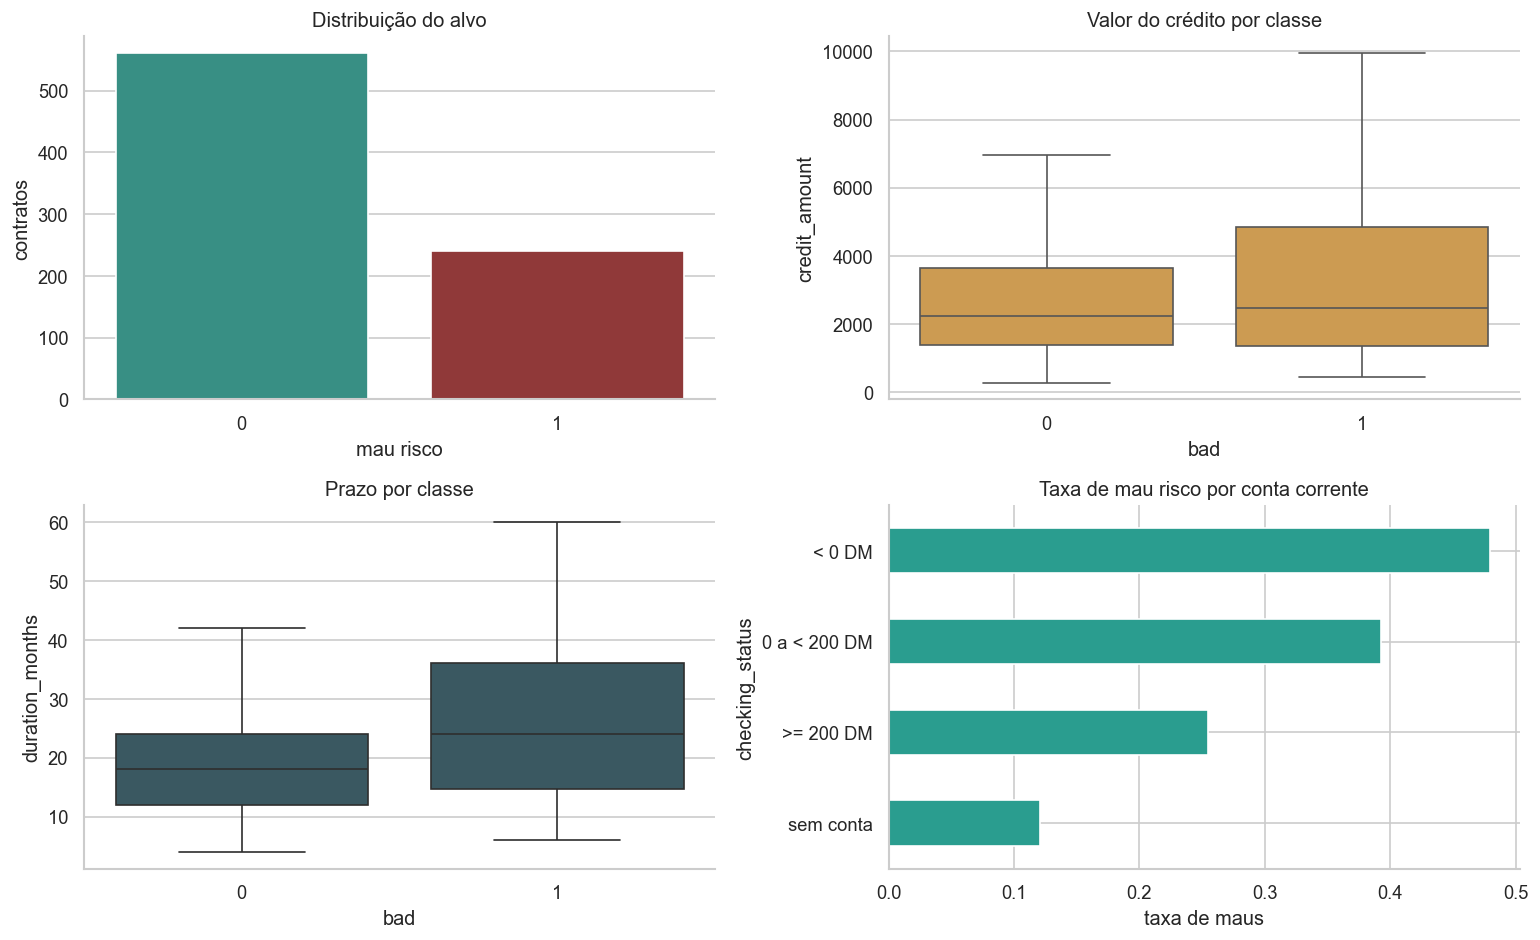

In [9]:
def decode_for_analysis(frame):
    out = frame.copy()
    for column, mapping in CODE_MAPS.items():
        if column in out.columns:
            out[column] = out[column].map(mapping).fillna(out[column].astype(str))
    return out


eda = decode_for_analysis(X_train_raw)
eda["bad"] = y_train.to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sns.countplot(data=eda, x="bad", hue="bad", legend=False, ax=axes[0, 0], palette=["#2A9D8F", "#9E2A2B"])
axes[0, 0].set(title="Distribuição do alvo", xlabel="mau risco", ylabel="contratos")

sns.boxplot(data=eda, x="bad", y="credit_amount", ax=axes[0, 1], color="#E09F3E", showfliers=False)
axes[0, 1].set_title("Valor do crédito por classe")

sns.boxplot(data=eda, x="bad", y="duration_months", ax=axes[1, 0], color="#335C67", showfliers=False)
axes[1, 0].set_title("Prazo por classe")

rate_checking = eda.groupby("checking_status")["bad"].agg(["mean", "size"]).sort_values("mean")
rate_checking.plot.barh(y="mean", legend=False, ax=axes[1, 1], color="#2A9D8F")
axes[1, 1].set(title="Taxa de mau risco por conta corrente", xlabel="taxa de maus")

plt.tight_layout()
plt.show()

In [10]:
categorical_rates = []
for column in ["credit_history", "purpose", "savings_status", "employment_since", "housing"]:
    temp = eda.groupby(column)["bad"].agg(["mean", "size"]).reset_index()
    temp["attribute"] = column
    temp = temp.rename(columns={column: "category", "mean": "bad_rate", "size": "n"})
    categorical_rates.append(temp)

categorical_rates = pd.concat(categorical_rates, ignore_index=True)
categorical_rates.sort_values(["attribute", "bad_rate"], ascending=[True, False]).head(20)

,category,bad_rate,n,attribute
4,sem credito,0.6129,31,credit_history
3,creditos pagos no banco,0.5366,41,credit_history
2,creditos em dia,0.3221,416,credit_history
0,atrasos passados,0.3194,72,credit_history
1,conta critica,0.1750,240,credit_history
22,< 1 ano,0.4406,143,employment_since
24,desempregado,0.4146,41,employment_since
20,1 a < 4 anos,0.2768,271,employment_since
23,>= 7 anos,0.2621,206,employment_since
21,4 a < 7 anos,0.2230,139,employment_since


**Leitura técnica:** conta corrente, histórico, valor e prazo apresentam associações com o alvo. Árvores podem capturar cortes e interações. Categorias com poucos contratos produzem taxas instáveis e podem virar regras frágeis.

**Leitura comercial:** a taxa de mau risco não mede retorno do contrato. Juros, exposição no default, recuperação e prazo não estão disponíveis. O notebook resolve classificação sob a matriz 5:1, não precificação nem perda esperada.

### Pergunta profunda 2

Por que não aplicar SMOTE ou oversampling imediatamente?

<details>
<summary>Resposta guiada</summary>

A classe má representa 30%, proporção suficiente para validar modelos. A matriz de custo pode ser tratada no limiar. Reamostragem altera a prevalência vista pelo estimador, pode prejudicar calibração e precisa ocorrer dentro dos folds. Ela seria um experimento, não uma etapa automática.

</details>

## 7. Árvore rasa e estabilidade das regras

Uma árvore de profundidade 3 será usada para aprender o mecanismo. Depois, 100 amostras bootstrap mostrarão quantas vezes a primeira divisão muda.

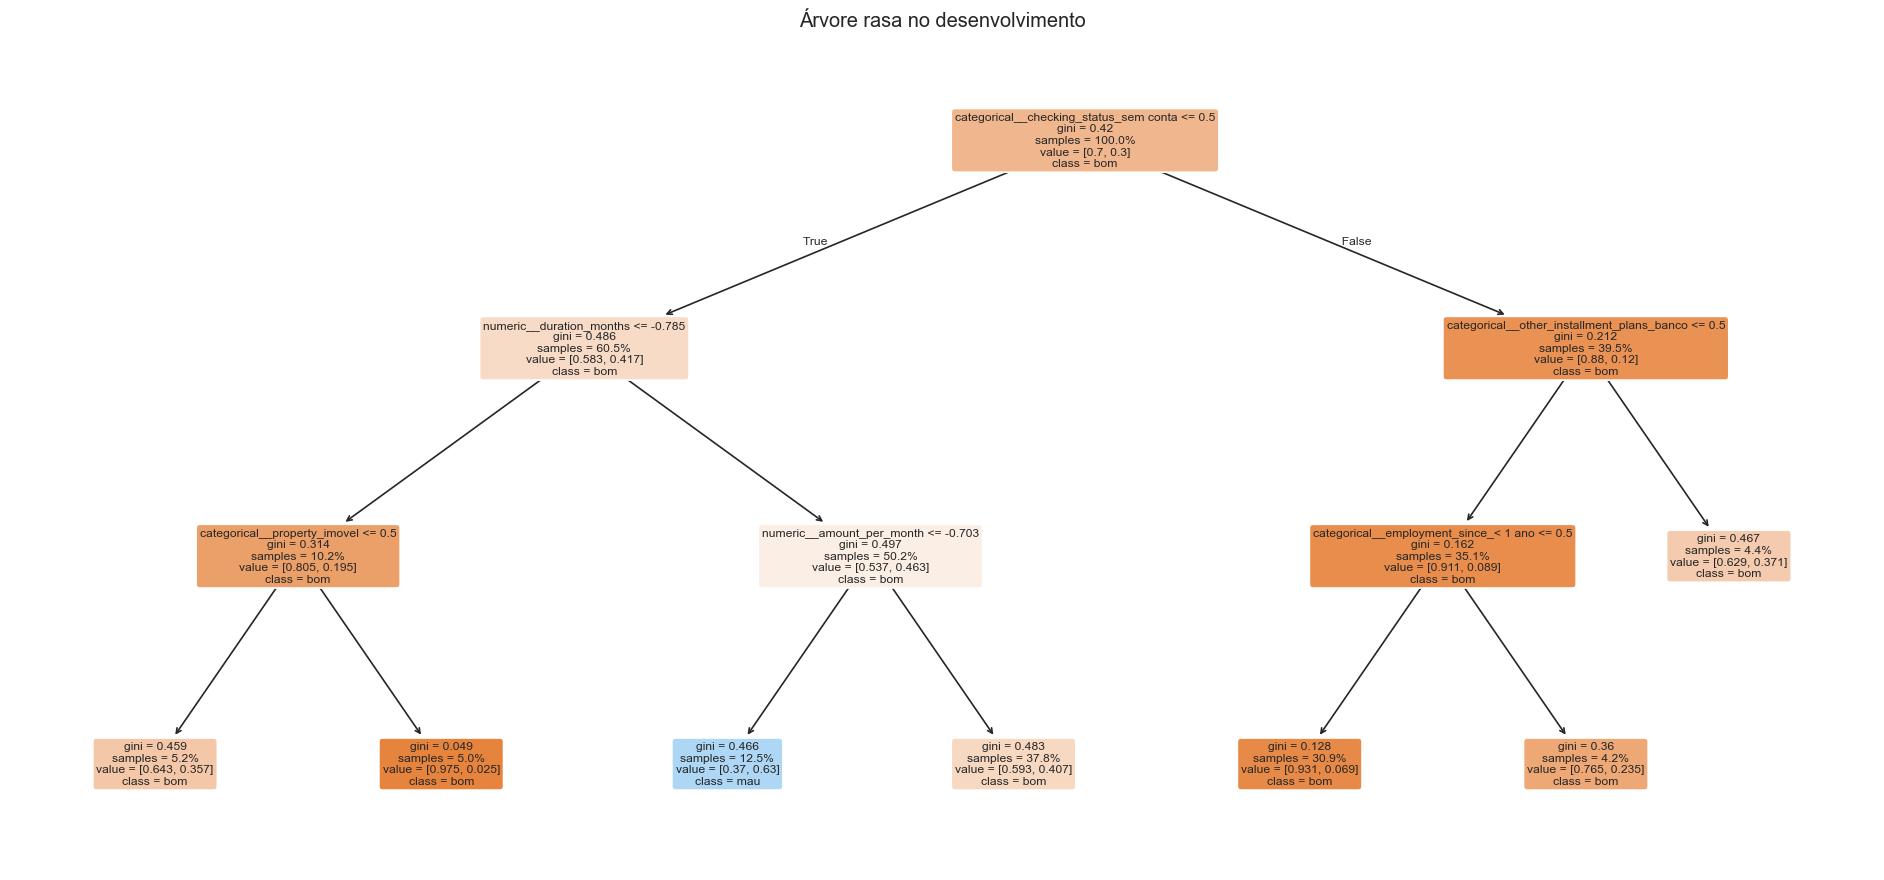

In [11]:
demo_engineer = GermanCreditFeatureEngineer(add_domain_features=True)
demo_preprocess = make_preprocessor(MODEL_FEATURES, add_domain_features=True)
Z_train = demo_preprocess.fit_transform(demo_engineer.fit_transform(X_train))
feature_names = demo_preprocess.get_feature_names_out()

shallow_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=SEED)
shallow_tree.fit(Z_train, y_train)

fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(
    shallow_tree,
    feature_names=feature_names,
    class_names=["bom", "mau"],
    filled=True,
    rounded=True,
    proportion=True,
    precision=3,
    ax=ax,
)
ax.set_title("Árvore rasa no desenvolvimento")
plt.show()

In [12]:
root_index = shallow_tree.tree_.feature[0]
root_name = feature_names[root_index]
root_threshold = shallow_tree.tree_.threshold[0]
display(Markdown(f"""
**Raiz da árvore:** `{root_name}` com limiar **{root_threshold:.3f}**.
A regra é uma descrição da amostra. Ela não prova que alterar a variável mudaria o risco.
"""))
print(export_text(shallow_tree, feature_names=list(feature_names), max_depth=3))


**Raiz da árvore:** `categorical__checking_status_sem conta` com limiar **0.500**.
A regra é uma descrição da amostra. Ela não prova que alterar a variável mudaria o risco.


|--- categorical__checking_status_sem conta <= 0.50
|   |--- numeric__duration_months <= -0.78
|   |   |--- categorical__property_imovel <= 0.50
|   |   |   |--- class: 0
|   |   |--- categorical__property_imovel >  0.50
|   |   |   |--- class: 0
|   |--- numeric__duration_months >  -0.78
|   |   |--- numeric__amount_per_month <= -0.70
|   |   |   |--- class: 1
|   |   |--- numeric__amount_per_month >  -0.70
|   |   |   |--- class: 0
|--- categorical__checking_status_sem conta >  0.50
|   |--- categorical__other_installment_plans_banco <= 0.50
|   |   |--- categorical__employment_since_< 1 ano <= 0.50
|   |   |   |--- class: 0
|   |   |--- categorical__employment_since_< 1 ano >  0.50
|   |   |   |--- class: 0
|   |--- categorical__other_installment_plans_banco >  0.50
|   |   |--- class: 0



In [13]:
rng = np.random.default_rng(SEED)
root_features = []
for b in range(100):
    sample_idx = rng.choice(len(Z_train), size=len(Z_train), replace=True)
    tree_b = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=SEED + b)
    tree_b.fit(Z_train[sample_idx], y_train.to_numpy()[sample_idx])
    idx = tree_b.tree_.feature[0]
    root_features.append(feature_names[idx] if idx >= 0 else "sem divisao")

root_stability = pd.Series(root_features).value_counts(normalize=True).head(10).rename("frequencia").to_frame()
root_stability

,frequencia
categorical__checking_status_sem conta,0.9900
numeric__credit_amount,0.0100


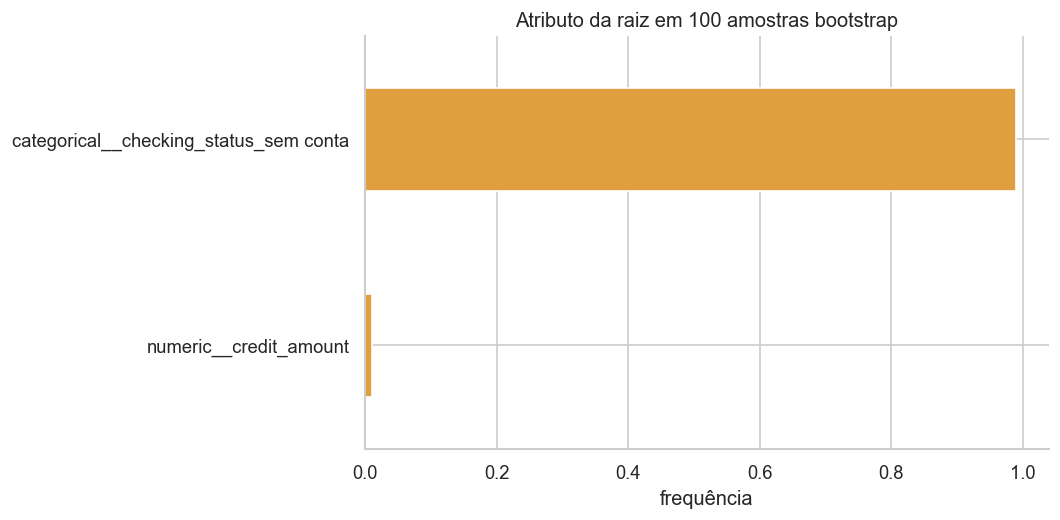

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
root_stability.sort_values("frequencia").plot.barh(y="frequencia", legend=False, ax=ax, color="#E09F3E")
ax.set(title="Atributo da raiz em 100 amostras bootstrap", xlabel="frequência", ylabel="")
plt.tight_layout()
plt.show()

**Interpretação:** se a raiz muda entre amostras, uma regra única tem alta incerteza estrutural. Bagging usa essa instabilidade a favor: várias árvores diferentes são agregadas, reduzindo a dependência de uma divisão específica.

### Pergunta profunda 3

Se a árvore rasa é interpretável, por que não usá-la diretamente?

<details>
<summary>Resposta guiada</summary>

Interpretabilidade local não compensa instabilidade. Uma regra fácil de ler pode mudar com pequenas alterações da amostra. Ela precisa ser avaliada fora do treino e, em crédito, documentada junto com erro e impacto.

</details>

## 8. Poda por complexidade de custo

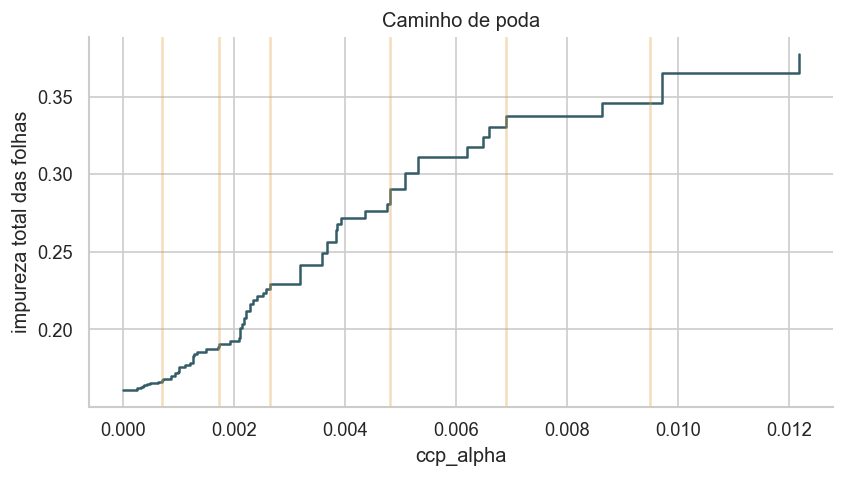

,ccp_alpha candidato
0,0.0000
1,0.0007
2,0.0017
3,0.0026
4,0.0048
5,0.0069
6,0.0095


In [16]:
path_tree = DecisionTreeClassifier(min_samples_leaf=5, random_state=SEED)
path = path_tree.cost_complexity_pruning_path(Z_train, y_train)
valid_alphas = path.ccp_alphas[:-1]
alpha_grid = np.unique(np.r_[0.0, np.quantile(valid_alphas, [0.25, 0.50, 0.70, 0.85, 0.95, 0.98])])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(path.ccp_alphas[:-1], path.impurities[:-1], drawstyle="steps-post", color="#335C67")
for alpha in alpha_grid[1:]:
    ax.axvline(alpha, color="#E09F3E", alpha=0.35)
ax.set(title="Caminho de poda", xlabel="ccp_alpha", ylabel="impureza total das folhas")
plt.show()

pd.Series(alpha_grid, name="ccp_alpha candidato").to_frame()

In [17]:
cv_pruning = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
pruning_pipeline = make_pipeline(
    DecisionTreeClassifier(min_samples_leaf=5, random_state=SEED)
)
pruning_search = GridSearchCV(
    pruning_pipeline,
    {"model__ccp_alpha": alpha_grid},
    scoring="average_precision",
    cv=cv_pruning,
    return_train_score=True,
    n_jobs=1,
)
pruning_search.fit(X_train, y_train)

pruning_results = pd.DataFrame(pruning_search.cv_results_)[[
    "param_model__ccp_alpha", "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"
]].rename(columns={
    "param_model__ccp_alpha": "ccp_alpha",
    "mean_train_score": "AP_train",
    "mean_test_score": "AP_validation",
    "std_test_score": "AP_std",
    "rank_test_score": "rank",
}).sort_values("ccp_alpha")

best_alpha = float(pruning_search.best_params_["model__ccp_alpha"])
pruning_results

,ccp_alpha,AP_train,AP_validation,AP_std,rank
0,0.0000,0.8935,0.4438,0.0214,6
1,0.0007,0.8901,0.4670,0.0166,4
2,0.0017,0.8626,0.4749,0.0160,3
3,0.0026,0.8275,0.4881,0.0170,2
4,0.0048,0.6972,0.4933,0.0630,1
5,0.0069,0.5706,0.4495,0.0405,5
6,0.0095,0.5145,0.4222,0.0567,7


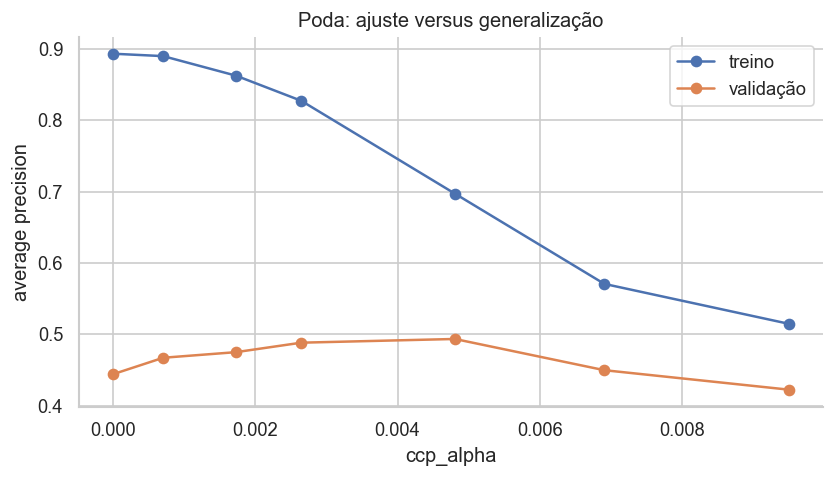

**`ccp_alpha` selecionado dentro do desenvolvimento: 0.004806.**

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pruning_results["ccp_alpha"], pruning_results["AP_train"], marker="o", label="treino")
ax.plot(pruning_results["ccp_alpha"], pruning_results["AP_validation"], marker="o", label="validação")
ax.set(title="Poda: ajuste versus generalização", xlabel="ccp_alpha", ylabel="average precision")
ax.legend()
plt.show()

display(Markdown(f"**`ccp_alpha` selecionado dentro do desenvolvimento: {best_alpha:.6f}.**"))

## 9. Candidatos e validação repetida

O tamanho da amostra torna uma única divisão instável. Será usada validação cruzada estratificada com 5 folds e 3 repetições. Os mesmos 15 folds avaliam todos os candidatos.

Modelos:

- dummy pela prevalência;
- regressão logística como baseline paramétrico;
- CART livre;
- CART podada;
- bagging;
- random forest;
- gradient boosting com árvores rasas.

AP é a métrica primária de seleção. ROC AUC, Brier, log loss, tempo e gap entre treino e validação ajudam a interpretar o resultado.

In [19]:
candidates = {
    "Dummy": DummyClassifier(strategy="prior"),
    "Regressao logistica": LogisticRegression(max_iter=3000),
    "CART livre": DecisionTreeClassifier(random_state=SEED),
    "CART podada": DecisionTreeClassifier(min_samples_leaf=5, ccp_alpha=best_alpha, random_state=SEED),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(min_samples_leaf=5, random_state=SEED),
        n_estimators=150,
        max_samples=0.80,
        oob_score=True,
        n_jobs=1,
        random_state=SEED,
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=250,
        min_samples_leaf=5,
        max_features="sqrt",
        oob_score=True,
        n_jobs=1,
        random_state=SEED,
    ),
    "Gradient boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.03,
        max_depth=2,
        min_samples_leaf=10,
        random_state=SEED,
    ),
}

cv_repeated = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
cv_rows = []
cv_fold_rows = []

for name, estimator in candidates.items():
    pipeline = make_pipeline(estimator)
    start = time.perf_counter()
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv_repeated,
        scoring={
            "AP": "average_precision",
            "ROC_AUC": "roc_auc",
            "neg_log_loss": "neg_log_loss",
            "neg_Brier": "neg_brier_score",
        },
        return_train_score=True,
        n_jobs=1,
    )
    elapsed = time.perf_counter() - start
    cv_rows.append({
        "model": name,
        "AP_mean": scores["test_AP"].mean(),
        "AP_std": scores["test_AP"].std(ddof=1),
        "AP_train": scores["train_AP"].mean(),
        "ROC_AUC": scores["test_ROC_AUC"].mean(),
        "log_loss": -scores["test_neg_log_loss"].mean(),
        "Brier": -scores["test_neg_Brier"].mean(),
        "time_s": elapsed,
    })
    for fold, ap in enumerate(scores["test_AP"], start=1):
        cv_fold_rows.append({"model": name, "fold": fold, "AP": ap})

cv_summary = pd.DataFrame(cv_rows).sort_values("AP_mean", ascending=False).reset_index(drop=True)
cv_summary["AP_gap"] = cv_summary["AP_train"] - cv_summary["AP_mean"]
cv_folds = pd.DataFrame(cv_fold_rows)
cv_summary

,model,AP_mean,AP_std,AP_train,ROC_AUC,log_loss,Brier,time_s,AP_gap
0,Random forest,0.6282,0.0697,0.9177,0.7908,0.5030,0.1668,6.6188,0.2895
1,Bagging,0.6172,0.0690,0.9340,0.7834,0.4986,0.1656,7.5319,0.3168
2,Regressao logistica,0.5850,0.0672,0.6934,0.7658,0.5232,0.1750,1.3008,0.1083
3,Gradient boosting,0.5644,0.0651,0.7676,0.7634,0.5200,0.1739,3.8321,0.2033
4,CART podada,0.4986,0.0562,0.6906,0.7136,0.9045,0.1962,0.7981,0.1920
5,CART livre,0.4036,0.0386,1.0000,0.6427,10.7831,0.2992,0.8077,0.5964
6,Dummy,0.3000,0.0000,0.3000,0.5000,0.6109,0.2100,0.7829,0.0000


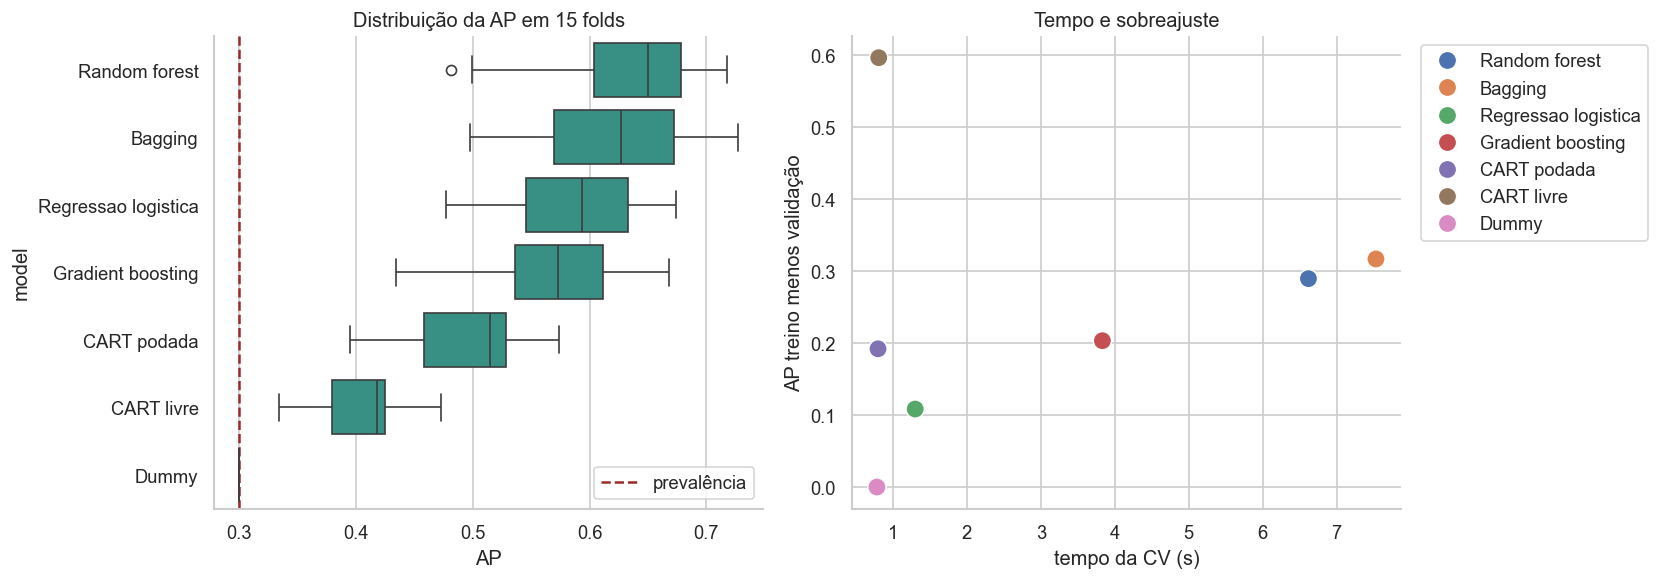

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = cv_summary["model"].tolist()
sns.boxplot(data=cv_folds, y="model", x="AP", order=order, ax=axes[0], color="#2A9D8F")
axes[0].axvline(y_train.mean(), linestyle="--", color="#9E2A2B", label="prevalência")
axes[0].set_title("Distribuição da AP em 15 folds")
axes[0].legend()

sns.scatterplot(data=cv_summary, x="time_s", y="AP_gap", hue="model", s=120, ax=axes[1])
axes[1].set(title="Tempo e sobreajuste", xlabel="tempo da CV (s)", ylabel="AP treino menos validação")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [21]:
selected_name = cv_summary.iloc[0]["model"]
selected_estimator = candidates[selected_name]
selected_pipeline = make_pipeline(selected_estimator)
selected_row = cv_summary.iloc[0]

display(Markdown(f"""
### Família congelada: {selected_name}

- AP média: **{selected_row.AP_mean:.3f} ± {selected_row.AP_std:.3f}**;
- ROC AUC média: **{selected_row.ROC_AUC:.3f}**;
- Brier médio: **{selected_row.Brier:.3f}**;
- gap de AP: **{selected_row.AP_gap:.3f}**.

A incerteza entre folds permanece relevante. A seleção usa a média previamente definida e o teste continua fechado.
"""))


### Família congelada: Random forest

- AP média: **0.628 ± 0.070**;
- ROC AUC média: **0.791**;
- Brier médio: **0.167**;
- gap de AP: **0.289**.

A incerteza entre folds permanece relevante. A seleção usa a média previamente definida e o teste continua fechado.


### Pergunta profunda 4

Se os intervalos dos modelos se sobrepõem, faz sentido declarar um vencedor absoluto?

<details>
<summary>Resposta guiada</summary>

Não há evidência de superioridade absoluta. O modelo selecionado é o melhor sob este protocolo e esta amostra. Tempo, tamanho, calibração, estabilidade e governança podem justificar outra escolha quando a diferença média é pequena.

</details>

## 10. O que a engenharia de atributos e a governança custaram

Dois experimentos internos serão feitos com a família selecionada:

1. atributos originais contra atributos de domínio;
2. todas as colunas contra exclusão das três colunas sensíveis.

Os experimentos usam apenas o desenvolvimento e cinco folds. Eles servem para diagnóstico, não para reabrir uma busca ilimitada.

In [22]:
diagnostic_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

feature_rows = []
for add_features in [False, True]:
    pipe = make_pipeline(selected_estimator, add_domain_features=add_features)
    scores = cross_validate(
        pipe, X_train, y_train, cv=diagnostic_cv,
        scoring={"AP": "average_precision", "AUC": "roc_auc", "Brier": "neg_brier_score"},
        n_jobs=1,
    )
    feature_rows.append({
        "cenario": "com engenharia" if add_features else "somente originais",
        "AP": scores["test_AP"].mean(),
        "ROC_AUC": scores["test_AUC"].mean(),
        "Brier": -scores["test_Brier"].mean(),
    })

feature_comparison = pd.DataFrame(feature_rows)
feature_comparison

,cenario,AP,ROC_AUC,Brier
0,somente originais,0.6249,0.7860,0.1679
1,com engenharia,0.6238,0.7876,0.1672


In [23]:
governance_rows = []
for scenario, features in [("todas as colunas", RAW_FEATURES), ("politica de governanca", MODEL_FEATURES)]:
    frame = X_train_raw[features]
    pipe = make_pipeline(selected_estimator, input_features=features, add_domain_features=True)
    scores = cross_validate(
        pipe, frame, y_train, cv=diagnostic_cv,
        scoring={"AP": "average_precision", "AUC": "roc_auc", "Brier": "neg_brier_score"},
        n_jobs=1,
    )
    governance_rows.append({
        "cenario": scenario,
        "AP": scores["test_AP"].mean(),
        "ROC_AUC": scores["test_AUC"].mean(),
        "Brier": -scores["test_Brier"].mean(),
    })

governance_comparison = pd.DataFrame(governance_rows)
governance_comparison

,cenario,AP,ROC_AUC,Brier
0,todas as colunas,0.6334,0.7977,0.1660
1,politica de governanca,0.6238,0.7876,0.1672


In [24]:
delta_feature = feature_comparison.set_index("cenario").loc["com engenharia", "AP"] - feature_comparison.set_index("cenario").loc["somente originais", "AP"]
delta_governance = governance_comparison.set_index("cenario").loc["politica de governanca", "AP"] - governance_comparison.set_index("cenario").loc["todas as colunas", "AP"]

# Regra de parcimônia definida no desenvolvimento: manter atributos derivados
# somente quando o ganho de AP superar 0,005.
USE_DOMAIN_FEATURES = bool(delta_feature > 0.005)
feature_decision = "mantidos" if USE_DOMAIN_FEATURES else "removidos"
selected_pipeline = make_pipeline(
    selected_estimator,
    add_domain_features=USE_DOMAIN_FEATURES,
)

display(Markdown(f"""
**Engenharia de domínio:** variação de AP de **{delta_feature:+.3f}**.

**Exclusão de governança:** variação de AP de **{delta_governance:+.3f}**.

**Decisão de parcimônia:** atributos derivados **{feature_decision}** no pipeline final.
A decodificação, imputação, escala e one-hot continuam serializadas. As colunas sensíveis permanecem excluídas.
"""))


**Engenharia de domínio:** variação de AP de **-0.001**.

**Exclusão de governança:** variação de AP de **-0.010**.

**Decisão de parcimônia:** atributos derivados **removidos** no pipeline final.
A decodificação, imputação, escala e one-hot continuam serializadas. As colunas sensíveis permanecem excluídas.


## 11. Out-of-bag e o limite da acurácia

Bagging e random forest permitem estimativa OOB. O scikit-learn reporta acurácia. Como 70% da amostra é boa, prever todos como bons já produz 70%.

In [25]:
oob_rows = []
for name in ["Bagging", "Random forest"]:
    pipe = make_pipeline(
        candidates[name],
        add_domain_features=USE_DOMAIN_FEATURES,
    ).fit(X_train, y_train)
    oob_rows.append({"model": name, "OOB_accuracy": pipe.named_steps["model"].oob_score_})

oob_table = pd.DataFrame(oob_rows)
oob_table["majority_baseline"] = 1 - y_train.mean()
oob_table["gain"] = oob_table["OOB_accuracy"] - oob_table["majority_baseline"]
oob_table

,model,OOB_accuracy,majority_baseline,gain
0,Bagging,0.7562,0.7000,0.0563
1,Random forest,0.7588,0.7000,0.0588


**Interpretação:** OOB ajuda a diagnosticar ensembles, mas acurácia não representa o custo 5:1. A validação repetida continua sendo a base da seleção.

## 12. Ajuste do limiar com previsões fora do fold

O modelo selecionado gerará probabilidades OOF no desenvolvimento. O limiar empírico minimizará:

$$C(t)=5\,FN(t)+1\,FP(t).$$

Se as probabilidades fossem perfeitamente calibradas e esses fossem os únicos custos, o limiar teórico para classificar como mau seria:

$$t^*=\frac{C_{FP}}{C_{FN}+C_{FP}}=\frac{1}{5+1}=0{,}167.$$

O limiar empírico pode diferir por calibração imperfeita e variação da amostra.

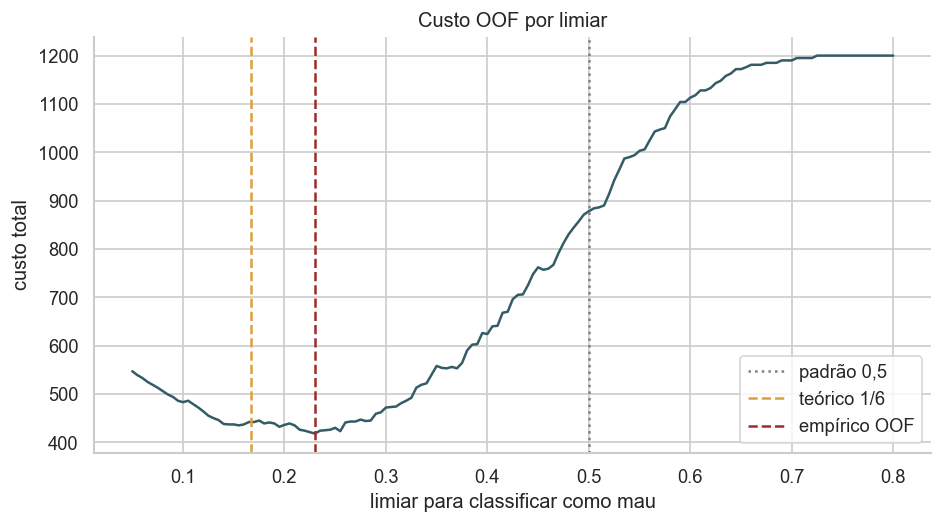

Limiar teórico: 0.167
Limiar empírico congelado: 0.230


In [27]:
threshold_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
p_oof = cross_val_predict(
    selected_pipeline,
    X_train,
    y_train,
    cv=threshold_cv,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

def decision_cost(y_true, probability, threshold):
    pred_bad = probability >= threshold
    false_good = ((np.asarray(y_true) == 1) & (~pred_bad)).sum()
    false_bad = ((np.asarray(y_true) == 0) & pred_bad).sum()
    return COST_FALSE_GOOD * false_good + COST_FALSE_BAD * false_bad


threshold_grid = np.linspace(0.05, 0.80, 151)
cost_curve = pd.DataFrame({
    "threshold": threshold_grid,
    "cost": [decision_cost(y_train, p_oof, t) for t in threshold_grid],
})
empirical_threshold = float(cost_curve.loc[cost_curve["cost"].idxmin(), "threshold"])
theoretical_threshold = COST_FALSE_BAD / (COST_FALSE_GOOD + COST_FALSE_BAD)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(cost_curve["threshold"], cost_curve["cost"], color="#335C67")
ax.axvline(0.5, linestyle=":", color="gray", label="padrão 0,5")
ax.axvline(theoretical_threshold, linestyle="--", color="#E09F3E", label="teórico 1/6")
ax.axvline(empirical_threshold, linestyle="--", color="#9E2A2B", label="empírico OOF")
ax.set(title="Custo OOF por limiar", xlabel="limiar para classificar como mau", ylabel="custo total")
ax.legend()
plt.show()

print(f"Limiar teórico: {theoretical_threshold:.3f}")
print(f"Limiar empírico congelado: {empirical_threshold:.3f}")

### Pergunta profunda 5

Por que não usar o teste para encontrar o menor custo?

<details>
<summary>Resposta guiada</summary>

O teste mede a política completa, incluindo o limiar. Ajustar nele usa os rótulos finais para melhorar a decisão e elimina a função de avaliação independente.

</details>

## 13. Reajuste final e abertura única do teste

In [28]:
fit_start = time.perf_counter()
final_pipeline = clone(selected_pipeline).fit(X_train, y_train)
fit_seconds = time.perf_counter() - fit_start

predict_start = time.perf_counter()
p_test = final_pipeline.predict_proba(X_test)[:, 1]
latency_ms_1000 = (time.perf_counter() - predict_start) * 1000 / len(X_test) * 1000

fpr, tpr, _ = roc_curve(y_test, p_test)
test_auc = roc_auc_score(y_test, p_test)
test_metrics = pd.Series({
    "AP": average_precision_score(y_test, p_test),
    "ROC_AUC": test_auc,
    "Gini": 2 * test_auc - 1,
    "KS": np.max(tpr - fpr),
    "log_loss": log_loss(y_test, p_test),
    "Brier": brier_score_loss(y_test, p_test),
    "probability_mean": p_test.mean(),
}, name=selected_name)

print(f"Tempo de ajuste final: {fit_seconds:.2f} s")
print(f"Latência aproximada: {latency_ms_1000:.2f} ms por 1.000 contratos")
test_metrics.to_frame()

Tempo de ajuste final: 0.41 s
Latência aproximada: 154.54 ms por 1.000 contratos


,Random forest
AP,0.6378
ROC_AUC,0.7846
Gini,0.5693
KS,0.5357
log_loss,0.5082
Brier,0.1662
probability_mean,0.3078


In [29]:
def threshold_metrics(name, threshold):
    pred = (p_test >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {
        "policy": name,
        "threshold": threshold,
        "TN_good_approved": tn,
        "FP_good_rejected": fp,
        "FN_bad_approved": fn,
        "TP_bad_rejected": tp,
        "recall_bad": recall_score(y_test, pred),
        "precision_bad": precision_score(y_test, pred, zero_division=0),
        "cost": COST_FALSE_GOOD * fn + COST_FALSE_BAD * fp,
    }


policy_table = pd.DataFrame([
    threshold_metrics("padrão 0,5", 0.5),
    threshold_metrics("teórico 1/6", theoretical_threshold),
    threshold_metrics("empírico OOF", empirical_threshold),
    {
        "policy": "aprovar todos", "threshold": np.nan,
        "TN_good_approved": int((y_test == 0).sum()), "FP_good_rejected": 0,
        "FN_bad_approved": int((y_test == 1).sum()), "TP_bad_rejected": 0,
        "recall_bad": 0.0, "precision_bad": 0.0,
        "cost": COST_FALSE_GOOD * int((y_test == 1).sum()),
    },
    {
        "policy": "recusar todos", "threshold": np.nan,
        "TN_good_approved": 0, "FP_good_rejected": int((y_test == 0).sum()),
        "FN_bad_approved": 0, "TP_bad_rejected": int((y_test == 1).sum()),
        "recall_bad": 1.0, "precision_bad": y_test.mean(),
        "cost": COST_FALSE_BAD * int((y_test == 0).sum()),
    },
]).sort_values("cost")
policy_table

,policy,threshold,TN_good_approved,FP_good_rejected,FN_bad_approved,TP_bad_rejected,recall_bad,precision_bad,cost
1,teórico 1/6,0.1667,42,98,3,57,0.9500,0.3677,113
2,empírico OOF,0.2300,66,74,9,51,0.8500,0.4080,119
4,recusar todos,NaN,0,140,0,60,1.0000,0.3000,140
0,"padrão 0,5",0.5000,128,12,37,23,0.3833,0.6571,197
3,aprovar todos,NaN,140,0,60,0,0.0000,0.0000,300


In [30]:
chosen = policy_table.loc[policy_table["policy"].eq("empírico OOF")].iloc[0]
display(Markdown(f"""
### Leitura do teste

O modelo alcança AP **{test_metrics.AP:.3f}**, ROC AUC **{test_metrics.ROC_AUC:.3f}**,
Gini **{test_metrics.Gini:.3f}** e KS **{test_metrics.KS:.3f}**.

Com o limiar congelado de **{empirical_threshold:.3f}**, o custo é **{chosen.cost:.0f}**,
com **{chosen.FN_bad_approved:.0f}** maus aprovados e **{chosen.FP_good_rejected:.0f}** bons recusados.

O limiar 0,5 deve ser comparado com as políticas triviais. Uma boa probabilidade não garante uma boa decisão quando o custo é assimétrico.
"""))


### Leitura do teste

O modelo alcança AP **0.638**, ROC AUC **0.785**,
Gini **0.569** e KS **0.536**.

Com o limiar congelado de **0.230**, o custo é **119**,
com **9** maus aprovados e **74** bons recusados.

O limiar 0,5 deve ser comparado com as políticas triviais. Uma boa probabilidade não garante uma boa decisão quando o custo é assimétrico.


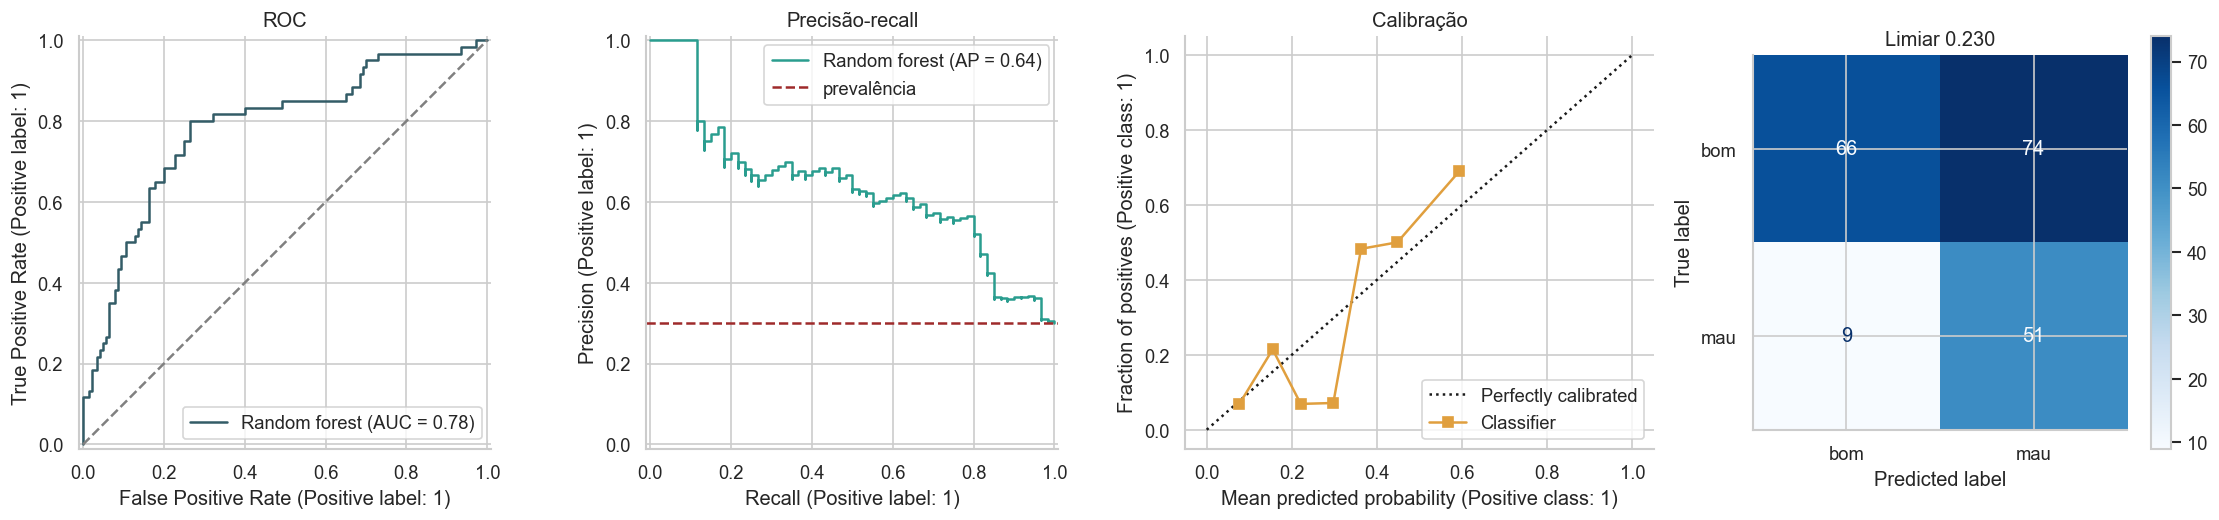

In [31]:
pred_test = (p_test >= empirical_threshold).astype(int)
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))

RocCurveDisplay.from_predictions(y_test, p_test, name=selected_name, ax=axes[0], color="#335C67")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("ROC")

PrecisionRecallDisplay.from_predictions(y_test, p_test, name=selected_name, ax=axes[1], color="#2A9D8F")
axes[1].axhline(y_test.mean(), linestyle="--", color="#9E2A2B", label="prevalência")
axes[1].set_title("Precisão-recall")
axes[1].legend()

CalibrationDisplay.from_predictions(y_test, p_test, n_bins=7, strategy="quantile", ax=axes[2], color="#E09F3E")
axes[2].set_title("Calibração")

ConfusionMatrixDisplay.from_predictions(y_test, pred_test, display_labels=["bom", "mau"], cmap="Blues", ax=axes[3])
axes[3].set_title(f"Limiar {empirical_threshold:.3f}")

plt.tight_layout()
plt.show()

**Leitura crítica:** Gini mede ordenação e vale $2\times AUC-1$. KS mede a maior separação entre distribuições acumuladas. Brier e calibração tratam probabilidades. A matriz de custo avalia a ação. Nenhuma métrica substitui as demais.

### Pergunta profunda 6

Um Gini maior garante custo menor?

<details>
<summary>Resposta guiada</summary>

Não. Gini avalia ordenação em todos os limiares. O custo depende do ponto escolhido, da prevalência, da calibração e dos pesos de erro. Dois modelos com Gini semelhante podem produzir custos diferentes.

</details>

## 14. Interpretação do modelo

Serão comparadas importância por impureza e importância por permutação. A primeira usa o treino e pode favorecer atributos com muitas divisões. A segunda embaralha uma coluna bruta no teste e mede a queda de AP.

In [32]:
model_final = final_pipeline.named_steps["model"]
preprocess_final = final_pipeline.named_steps["preprocess"]

if hasattr(model_final, "feature_importances_"):
    mdi = pd.DataFrame({
        "transformed_feature": preprocess_final.get_feature_names_out(),
        "MDI": model_final.feature_importances_,
    }).sort_values("MDI", ascending=False).head(15)
else:
    mdi = pd.DataFrame(columns=["transformed_feature", "MDI"])
    print("O estimador final não expõe feature_importances_.")

perm = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=20,
    random_state=SEED,
    n_jobs=1,
)
permutation_table = pd.DataFrame({
    "raw_feature": X_test.columns,
    "AP_drop_mean": perm.importances_mean,
    "AP_drop_std": perm.importances_std,
}).sort_values("AP_drop_mean", ascending=False)

display(mdi)
display(permutation_table.head(15))

,transformed_feature,MDI
9,categorical__checking_status_sem conta,0.1153
1,numeric__credit_amount,0.1145
0,numeric__duration_months,0.1030
7,categorical__checking_status_< 0 DM,0.0670
2,numeric__installment_rate,0.0393
11,categorical__credit_history_conta critica,0.0359
27,categorical__savings_status_< 100 DM,0.0335
3,numeric__residence_since,0.0297
6,categorical__checking_status_0 a < 200 DM,0.0277
32,categorical__employment_since_< 1 ano,0.0261


,raw_feature,AP_drop_mean,AP_drop_std
0,checking_status,0.1560,0.0384
4,credit_amount,0.0284,0.0116
3,purpose,0.0265,0.0119
8,other_debtors,0.0162,0.0069
7,installment_rate,0.0155,0.0113
2,credit_history,0.0153,0.0200
1,duration_months,0.0148,0.0199
14,job,0.0116,0.0151
9,residence_since,0.0109,0.0061
16,telephone,0.0017,0.0067


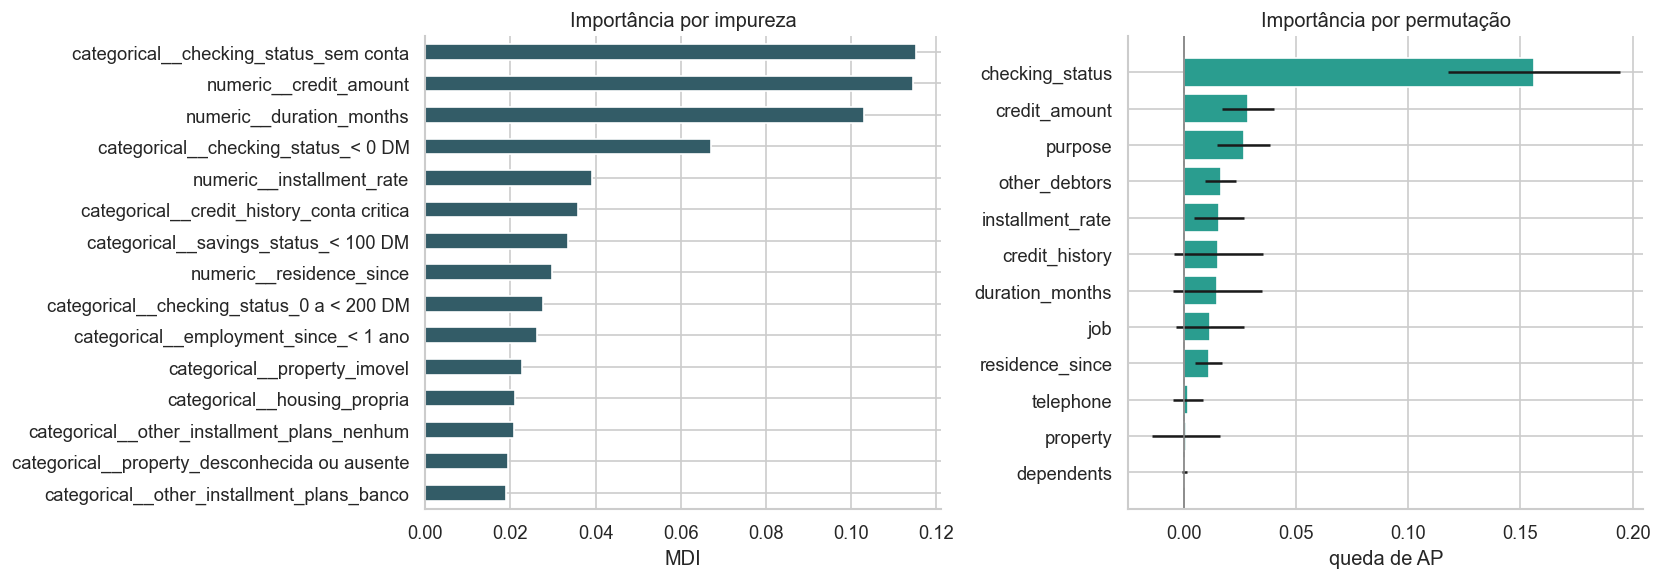

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if len(mdi):
    mdi.sort_values("MDI").plot.barh(x="transformed_feature", y="MDI", legend=False, ax=axes[0], color="#335C67")
axes[0].set(title="Importância por impureza", xlabel="MDI", ylabel="")

top_perm = permutation_table.head(12).sort_values("AP_drop_mean")
axes[1].barh(top_perm["raw_feature"], top_perm["AP_drop_mean"], xerr=top_perm["AP_drop_std"], color="#2A9D8F")
axes[1].axvline(0, color="gray", linewidth=1)
axes[1].set(title="Importância por permutação", xlabel="queda de AP", ylabel="")
plt.tight_layout()
plt.show()

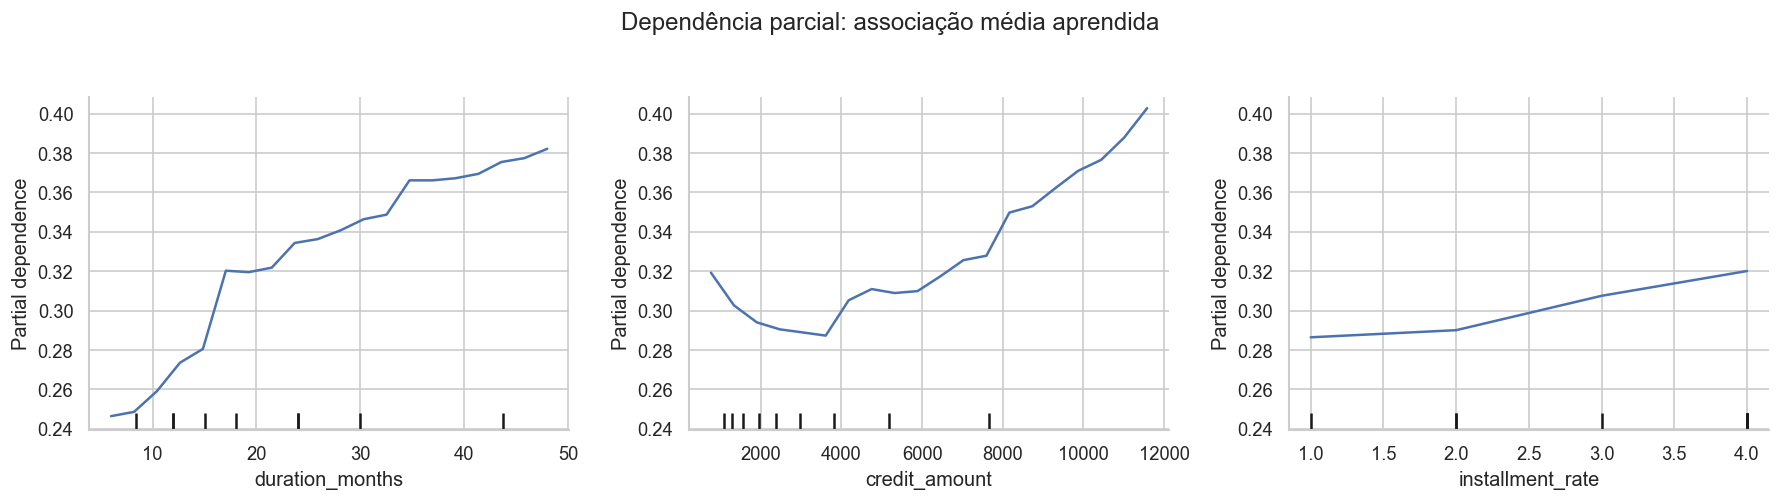

In [34]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(
    final_pipeline,
    X_test,
    features=["duration_months", "credit_amount", "installment_rate"],
    grid_resolution=20,
    kind="average",
    ax=ax,
)
fig.suptitle("Dependência parcial: associação média aprendida", y=1.04)
plt.tight_layout()
plt.show()

**Limite da interpretação:** permutação pode dividir importância entre atributos correlacionados. Dependência parcial cria combinações que podem ser raras. Os gráficos descrevem o modelo; não justificam aumentar prazo, reduzir valor ou alterar características pessoais como intervenção causal.

## 15. Análise dos erros de maior custo

O falso negativo em nossa codificação é um mau risco classificado como bom, com custo 5. O falso positivo é um bom risco classificado como mau, com custo 1.

In [35]:
error_frame = decode_for_analysis(X_test_raw).copy()
error_frame["bad"] = y_test.to_numpy()
error_frame["probability_bad"] = p_test
error_frame["predicted_bad"] = pred_test
error_frame["error_type"] = np.select(
    [
        (error_frame["bad"] == 1) & (error_frame["predicted_bad"] == 0),
        (error_frame["bad"] == 0) & (error_frame["predicted_bad"] == 1),
    ],
    ["mau aprovado: custo 5", "bom recusado: custo 1"],
    default="correto",
)

error_counts = error_frame["error_type"].value_counts().rename("contracts").to_frame()
numeric_error = error_frame.groupby("error_type")[["duration_months", "credit_amount", "installment_rate", "existing_credits"]].median()
display(error_counts)
display(numeric_error)

,contracts
error_type,
correto,117
bom recusado: custo 1,74
mau aprovado: custo 5,9


,duration_months,credit_amount,installment_rate,existing_credits
error_type,,,,
bom recusado: custo 1,18.0000,"2,571.0000",3.5000,1.0000
correto,18.0000,"2,302.0000",4.0000,1.0000
mau aprovado: custo 5,12.0000,"1,484.0000",3.0000,1.0000


In [36]:
costly_errors = error_frame.loc[error_frame["error_type"].eq("mau aprovado: custo 5")]
costly_profile = pd.concat({
    column: costly_errors[column].value_counts(normalize=True).head(5)
    for column in ["checking_status", "credit_history", "purpose", "savings_status"]
}, names=["attribute", "category"]).rename("share").to_frame()
costly_profile

share
attribute       category                      
checking_status sem conta               0.5556
                0 a < 200 DM            0.2222
                >= 200 DM               0.1111
                < 0 DM                  0.1111
credit_history  creditos em dia         0.7778
                conta critica           0.2222
purpose         carro novo              0.3333
                radio ou TV             0.3333
                negocio                 0.2222
                moveis                  0.1111
savings_status  < 100 DM                0.6667
                desconhecida ou ausente 0.1111
                500 a < 1000 DM         0.1111
                >= 1000 DM              0.1111

**Uso da análise:** segmentos de falsos negativos orientam revisão de dados, regras e amostragem. Eles não devem virar regras manuais sem nova validação. Com poucos erros, percentuais variam muito.

## 16. Auditoria por grupos excluídos

As variáveis sensíveis não entraram no modelo. Ainda assim, proxies podem gerar diferenças. Serão calculadas taxa de recusa, falso negativo e falso positivo por grupo.

In [37]:
audit = decode_for_analysis(X_test_raw[SENSITIVE_COLUMNS]).copy()
audit["age_group"] = pd.cut(audit["age"], bins=[0, 24, 34, 49, np.inf], labels=["até 24", "25-34", "35-49", "50+"])
audit["bad"] = y_test.to_numpy()
audit["predicted_bad"] = pred_test

def audit_group(frame, column):
    rows = []
    for group, g in frame.groupby(column, observed=True):
        bad_mask = g["bad"].eq(1)
        good_mask = ~bad_mask
        fnr = ((g["predicted_bad"] == 0) & bad_mask).sum() / bad_mask.sum() if bad_mask.sum() else np.nan
        fpr_group = ((g["predicted_bad"] == 1) & good_mask).sum() / good_mask.sum() if good_mask.sum() else np.nan
        rows.append({
            "attribute": column,
            "group": group,
            "n": len(g),
            "bad_rate": g["bad"].mean(),
            "rejection_rate": g["predicted_bad"].mean(),
            "FNR_bad_approved": fnr,
            "FPR_good_rejected": fpr_group,
        })
    return pd.DataFrame(rows)


audit_table = pd.concat([
    audit_group(audit, "personal_status_sex"),
    audit_group(audit, "age_group"),
    audit_group(audit, "foreign_worker"),
], ignore_index=True)
audit_table

,attribute,group,n,bad_rate,rejection_rate,FNR_bad_approved,FPR_good_rejected
0,personal_status_sex,homem casado ou viuvo,12,0.2500,0.5833,0.3333,0.5556
1,personal_status_sex,homem divorciado,9,0.3333,0.7778,0.0000,0.6667
2,personal_status_sex,homem solteiro,118,0.2881,0.6017,0.0882,0.4762
3,personal_status_sex,mulher divorciada ou casada,61,0.3279,0.6557,0.2500,0.6098
4,age_group,até 24,39,0.4872,0.7436,0.1579,0.6500
5,age_group,25-34,66,0.3333,0.6212,0.1818,0.5227
6,age_group,35-49,63,0.2063,0.5873,0.0769,0.5000
7,age_group,50+,32,0.1875,0.5625,0.1667,0.5000
8,foreign_worker,nao,6,0.1667,0.3333,0.0000,0.2000
9,foreign_worker,sim,194,0.3041,0.6340,0.1525,0.5407


**Leitura responsável:** grupos pequenos produzem taxas frágeis. Diferença de erro não prova discriminação nem ausência dela. Uma avaliação real exige definição jurídica de grupos, intervalos de confiança, dados representativos, análise de proxies, revisão humana e documentação de impacto.

### Pergunta profunda 7

Excluir uma coluna sensível elimina o risco de discriminação?

<details>
<summary>Resposta guiada</summary>

Não. Outras variáveis podem reconstruir parte da informação sensível. A própria base reflete decisões históricas e seleção de clientes. Exclusão é uma medida de governança, não uma prova de equidade.

</details>

## 17. Monitoramento e teste de estresse de dados

Sem timestamp, o holdout aleatório não mede drift real. O notebook mostra duas verificações:

1. PSI entre desenvolvimento e teste, interpretado como variação amostral;
2. cenário sintético com aumento de valor e prazo, interpretado como teste de estresse.

In [38]:
def psi_numeric(reference, current, bins=10):
    ref = pd.Series(reference).dropna().astype(float)
    cur = pd.Series(current).dropna().astype(float)
    edges = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    ref_p = pd.cut(ref, edges, include_lowest=True).value_counts(normalize=True, sort=False).clip(1e-6)
    cur_p = pd.cut(cur, edges, include_lowest=True).value_counts(normalize=True, sort=False).clip(1e-6)
    return float(((cur_p - ref_p) * np.log(cur_p / ref_p)).sum())


psi_holdout = pd.DataFrame({
    "feature": BASE_NUMERIC,
    "PSI_random_holdout": [psi_numeric(X_train_raw[c], X_test_raw[c]) for c in BASE_NUMERIC],
}).sort_values("PSI_random_holdout", ascending=False)

stress = X_test.copy()
stress["credit_amount"] = stress["credit_amount"] * 1.50
stress["duration_months"] = np.ceil(stress["duration_months"] * 1.20).astype(int)
stress.loc[stress.index[:10], "purpose"] = "A499"

psi_stress = pd.DataFrame({
    "feature": ["credit_amount", "duration_months"],
    "PSI_stress": [
        psi_numeric(X_train["credit_amount"], stress["credit_amount"]),
        psi_numeric(X_train["duration_months"], stress["duration_months"]),
    ],
})

p_stress = final_pipeline.predict_proba(stress)[:, 1]
display(psi_holdout)
display(psi_stress)
print(f"Probabilidade média original: {p_test.mean():.3f}")
print(f"Probabilidade média no estresse: {p_stress.mean():.3f}")

,feature,PSI_random_holdout
1,credit_amount,0.0405
0,duration_months,0.0286
2,installment_rate,0.0218
4,existing_credits,0.0106
3,residence_since,0.0019
5,dependents,0.0000


,feature,PSI_stress
0,credit_amount,0.4970
1,duration_months,0.6567


Probabilidade média original: 0.308
Probabilidade média no estresse: 0.325


**Interpretação:** `handle_unknown='ignore'` impede falha com `A499`, mas a categoria nova vira um vetor de zeros naquela variável. Robustez do código não equivale a conhecimento estatístico. Categorias novas, distribuição do escore, taxa de maus, Gini, KS, calibração e custo devem ser acompanhados por coorte.

## 18. Persistência do pipeline completo

O artefato incluirá:

- pipeline treinado;
- limiar empírico;
- esquema de entrada;
- colunas excluídas;
- matriz de custo;
- métricas e versões.

`cloudpickle` permite serializar a classe de engenharia definida no notebook. O arquivo continua exigindo ambiente compatível e nunca deve ser carregado de origem não confiável.

In [39]:
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)
MODEL_PATH = ARTIFACT_DIR / "pipeline_risco_credito_german.pkl"

bundle = {
    "pipeline": final_pipeline,
    "threshold": empirical_threshold,
    "raw_model_features": MODEL_FEATURES,
    "excluded_sensitive_features": SENSITIVE_COLUMNS,
    "target_definition": "bad=1 quando credit_quality=2",
    "cost_matrix": {"bad_approved": COST_FALSE_GOOD, "good_rejected": COST_FALSE_BAD},
    "selected_model": selected_name,
    "domain_features_enabled": USE_DOMAIN_FEATURES,
    "test_metrics": test_metrics.to_dict(),
    "versions": versions.to_dict(),
}

with MODEL_PATH.open("wb") as file:
    cloudpickle.dump(bundle, file, protocol=5)

print(f"Artefato: {MODEL_PATH.resolve()}")
print(f"Tamanho: {MODEL_PATH.stat().st_size / 1024**2:.2f} MB")

Artefato: C:\Users\daler\OneDrive\Documentos\python-scripts\ISLP\artifacts\pipeline_risco_credito_german.pkl
Tamanho: 2.41 MB


In [40]:
def validate_and_score(bundle_object, frame):
    expected = bundle_object["raw_model_features"]
    missing = sorted(set(expected) - set(frame.columns))
    forbidden = sorted(set(bundle_object["excluded_sensitive_features"]) & set(frame.columns))
    if missing:
        raise ValueError(f"Colunas obrigatórias ausentes: {missing}")
    if forbidden:
        raise ValueError(f"Colunas sensíveis proibidas: {forbidden}")
    aligned = frame.loc[:, expected]
    probability = bundle_object["pipeline"].predict_proba(aligned)[:, 1]
    decision = (probability >= bundle_object["threshold"]).astype(int)
    return pd.DataFrame({"probability_bad": probability, "decision_bad": decision}, index=frame.index)


with MODEL_PATH.open("rb") as file:
    loaded_bundle = pickle.load(file)

inference_sample = X_test.iloc[:5].sample(frac=1, axis=1, random_state=SEED).copy()
inference_sample["extra_api_field"] = "ignored_by_contract"
loaded_scores = validate_and_score(loaded_bundle, inference_sample)

assert np.allclose(loaded_scores["probability_bad"], p_test[:5])
loaded_scores

,probability_bad,decision_bad
30,0.3129,1
128,0.2983,1
289,0.5433,1
216,0.5439,1
966,0.2398,1


In [41]:
try:
    validate_and_score(loaded_bundle, inference_sample.drop(columns="credit_amount"))
except ValueError as exc:
    print("Falha controlada por coluna ausente:")
    print(exc)

try:
    forbidden_sample = inference_sample.copy()
    forbidden_sample["age"] = 35
    validate_and_score(loaded_bundle, forbidden_sample)
except ValueError as exc:
    print("\nFalha controlada por coluna proibida:")
    print(exc)

unknown_sample = X_test.iloc[[0]].copy()
unknown_sample["purpose"] = "A499"
print("\nCategoria nova aceita tecnicamente:")
display(validate_and_score(loaded_bundle, unknown_sample))

Falha controlada por coluna ausente:
Colunas obrigatórias ausentes: ['credit_amount']

Falha controlada por coluna proibida:
Colunas sensíveis proibidas: ['age']

Categoria nova aceita tecnicamente:


,probability_bad,decision_bad
30,0.3242,1


**Atuação simulada do cientista de dados:** o pickle reduz divergência entre treino e inferência. O contrato bloqueia ausência de coluna e uso acidental de atributos sensíveis. Uma API real ainda precisaria de versionamento, autenticação, testes, registro de decisões, monitoramento e processo de retorno.

## 19. Testes mínimos do artefato

In [42]:
assert set(loaded_bundle["raw_model_features"]) == set(MODEL_FEATURES)
assert not set(SENSITIVE_COLUMNS) & set(loaded_bundle["raw_model_features"])
assert 0 < loaded_bundle["threshold"] < 1

probe = validate_and_score(loaded_bundle, X_test.iloc[:50])
assert np.isfinite(probe["probability_bad"]).all()
assert probe["probability_bad"].between(0, 1).all()
assert set(probe["decision_bad"].unique()).issubset({0, 1})
assert np.allclose(probe["probability_bad"], p_test[:50])

print("6 verificações concluídas sem falhas.")

6 verificações concluídas sem falhas.


### Pergunta profunda 8

Por que salvar somente o estimador final seria insuficiente?

<details>
<summary>Resposta guiada</summary>

O estimador espera a matriz transformada na mesma ordem do treino. Sem decodificação, atributos derivados, imputação e one-hot, a produção pode criar outra matriz ou trocar colunas silenciosamente. O pipeline preserva a sequência completa.

</details>

## 20. Registro final de decisões

| Decisão | Justificativa | Limite |
| --- | --- | --- |
| German Credit simbólico | preserva categorias e matriz de custo | histórico, alemão e apenas 1.000 contratos |
| split estratificado 80/20 | mantém a prevalência e fecha o teste | não mede tempo nem separa clientes |
| CV 5×3 | expõe variação amostral | não substitui validação externa |
| regressão logística como baseline | crédito frequentemente tem estrutura aditiva forte | não captura todas as interações automaticamente |
| poda validada | controla variância da CART | grade limitada pelo desenvolvimento |
| custo 5:1 no limiar | segue a documentação da UCI | unidade abstrata, sem EAD, LGD ou receita |
| engenharia no pipeline | evita divergência treino-inferência | atributos derivados podem perder validade em outra carteira |
| exclusão de três colunas | reduz risco direto de uso sensível | proxies e viés histórico permanecem |
| pickle completo | conserva transformação e modelo | exige ambiente compatível e origem confiável |

## 21. Conclusão crítica

O projeto mostra por que árvores são úteis e perigosas em amostras pequenas. A CART fornece regras claras, mas o bootstrap revela instabilidade. A poda reduz sobreajuste. Bagging e random forest combinam árvores para controlar variância. Boosting oferece outra forma de reduzir erro, ajustando árvores em sequência.

A decisão final depende de mais que AUC. A matriz de custo muda o limiar, o número de maus aprovados e o custo total. O limiar padrão de 0,5 pode perder para uma política trivial. Gini e KS medem separação; Brier e calibração medem probabilidades; custo mede a ação.

### Bloqueios antes de produção

- definição incompleta do evento de mau crédito e do horizonte;
- ausência de data e identificador de cliente;
- moeda e população incompatíveis com uma carteira brasileira atual;
- matriz de custo abstrata;
- amostra pequena para auditoria por grupos;
- falta de validação temporal, externa e de estabilidade;
- falta de EAD, LGD, recuperação, juros e custo de capital;
- ausência de revisão jurídica, privacidade e processo de contestação.

O próximo projeto deveria usar dados de originação com timestamp, identificador anonimizado, performance em horizonte fixo e componentes econômicos da perda. A validação seria temporal por safra, com calibração em janela separada e teste externo.

## 22. Questões para estudo

1. Como o limiar muda se o custo do mau aprovado passar de 5 para 10?
2. O modelo escolhido continua vencendo quando o critério é Brier em vez de AP?
3. Como aplicar a regra de um desvio padrão para preferir um modelo mais simples?
4. O que muda se `class_weight` for usado no treinamento e o limiar continuar sendo ajustado?
5. Como construir validação agrupada se houver vários contratos por cliente?
6. Por que uma importância alta de conta corrente não prova causalidade?
7. Qual é a diferença entre custo de classificação e perda esperada $PD\times LGD\times EAD$?
8. Como calibrar probabilidades sem usar o teste final?
9. Quando BART seria útil neste problema?
10. Que documentação seria necessária para explicar uma recusa individual?

### Desafio

Implemente calibração sigmoidal e isotônica dentro de uma validação aninhada. Compare Brier, log loss, custo no limiar teórico e custo no limiar empírico. Verifique se a calibração aproxima os dois limiares.

## 23. Referências

### Materiais-base

- James, Witten, Hastie, Tibshirani e Taylor. *An Introduction to Statistical Learning with Applications in Python*, Capítulo 8.
- [Laboratório oficial do ISLP: Tree-Based Methods](https://github.com/intro-stat-learning/ISLP_labs/blob/stable/Ch08-baggboost-lab.ipynb).
- Notebooks anexados do Capítulo 8: árvore de decisão, bagging, random forest, boosting e exercícios aplicados.
- [Géron: projeto end-to-end de Machine Learning](https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb).
- [CreditRiskProject em português](https://github.com/IohanFaustino/CreditRiskProject/tree/main/notebooks/version/pt).
- [Curso de scikit-learn da Inria](https://inria.github.io/scikit-learn-mooc/toc.html).

### Dados e implementação

- [UCI: Statlog German Credit Data](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data).
- [scikit-learn: poda por complexidade de custo](https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html).
- [scikit-learn: ajuste de limiar sensível a custo](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cost_sensitive_learning.html).
- [scikit-learn: importância por permutação](https://scikit-learn.org/stable/modules/permutation_importance.html).
- [Inria: random forests](https://inria.github.io/scikit-learn-mooc/python_scripts/ensemble_random_forest.html).
- [Inria: gradient boosting](https://inria.github.io/scikit-learn-mooc/python_scripts/ensemble_gradient_boosting.html).

### Referências em português

- Silva, J. S. [Modelos de Predição de Risco de Crédito em Machine Learning](https://repositorio.unb.br/bitstream/10482/44727/1/2022_JuellineShelciSilva.pdf). Universidade de Brasília, 2022.
- [Análise de risco de crédito direcionada por modelagem](https://repositorio.unesp.br/bitstreams/631a2b38-de5a-4569-a62a-fb75d332581a/download). UNESP.
- Banco Central do Brasil. [Resolução CMN nº 4.557](https://www.bcb.gov.br/estabilidadefinanceira/exibenormativo?numero=4557&tipo=Resolu%C3%A7%C3%A3o), estrutura de gerenciamento de riscos e capital.

As referências orientaram o método. O notebook acrescenta estabilidade bootstrap, baseline logístico, matriz de custo, limiar OOF, Gini, KS, exclusões de governança, teste de estresse e persistência do pipeline.